# Проект: Прогнозирование вероятности клика (CTR) для Advandex

# Сontents

[Введение.](#0-bullet)

1. [Этап 1. Подготовка среды и загрузка данных.](#1-bullet)
    <br>[2.1. Подготовим библиотеки.](#1.1-bullet)
    <br>[2.2. Зафиксируем константу для воспроизводимости.](#1.2-bullet)
    <br>[2.3. Загрузим данные.](#1.3-bullet)

2. [Этап 2. Исследовательский анализ данных (EDA)](#2-bullet)
    <br>[2.1. Опишем базовую информацию о датасете.](#2.1-bullet)
    <br>[2.2. Анализ целевой переменной.](#2.2-bullet)
    <br>[2.3. Анализ признаков.](#2.3-bullet)
    <br>[2.4. Анализ пропущенных значений.](#2.4-bullet)
    <br>[2.5. Анализ категориальных признаков.](#2.5-bullet)
    <br>[2.6. Анализ выбросов и распределений.](#2.6-bullet)
    <br>[2.7. Корреляции.](#2.7-bullet)
    <br>[2.8. Выводы по EDA.](#2.8-bullet)

3. [Этап 3. Разделение данных на выборки.](#3-bullet)
    <br>[3.1. Разделим данные.](#3.1-bullet)
    <br>[3.2. Проверим разделение.](#3.2-bullet)

4. [Этап 4. Предобработка данных — построение пайплайнов.](#4-bullet)
    <br>[4.1. Создадим пайплайн для предобработки данных.](#4.1-bullet)
    <br>[4.2. Объединим пайплайны.](#4.2-bullet)

5. [Этап 5. Отбор признаков.](#5-bullet)
    <br>[5.1. Применим фильтрационные методы.](#5.1-bullet)
    <br>[5.2. Применим методы-обёртки.](#5.2-bullet)
    <br>[5.3. Выберем финальный набор признаков.](#5.3-bullet)

6. [Этап 6. Обучение базовой модели.](#6-bullet)
    <br>[6.1. Обучим `DummyClassifier`.](#6.1-bullet)
    <br>[6.2. Обучим `LogisticRegression`.](#6.2-bullet)
    <br>[6.3. Обучим `SVC`.](#6.3-bullet)
    <br>[6.4. Сравним модели.](#6.4-bullet)

7. [Этап 7. Подбор гиперпараметров: Grid Search с кросс-валидацией.](#7-bullet)
    <br>[7.1. Определим сетку гиперпараметров.](#7.1-bullet)
    <br>[7.2. Применим Grid Search.](#7.2-bullet)
    <br>[7.3. Составим таблицу результатов.](#7.3-bullet)

8. [Этап 8. Финальная модель.](#8-bullet)
    <br>[8.1. Обучим финальную модель.](#8.1-bullet)
    <br>[8.2. Посчитаем метрики на тестовой выборке.](#8.2-bullet)
    <br>[8.3. Проанализируем веса модели.](#8.3-bullet)

9. [Этап 9. Калибровка модели.](#9-bullet)
    <br>[9.1. Проверим текущую калибровку.](#9.1-bullet)
    <br>[9.2. Применим методы калибровки.](#9.2-bullet)
    <br>[9.3. Сравним модели до и после калибровки.](#9.3-bullet)
    
10. [Этап 10. Оценка качества калибровки.](#10-bullet)
    <br>[10.1. Посчитаем метрики калибровки.](#10.1-bullet)
    <br>[10.2. Сравним модели до и после калибровки.](#10.2-bullet)
    
11. [Этап 11. Финальный отчёт и выводы.](#11-bullet)
    <br>[8.1. Сведём все результаты в таблицу.](#11.1-bullet)
    <br>[8.2. Напишем выводы.](#11.2-bullet)
    <br>[8.3. Рекомендации.](#11.3-bullet)
    
12. [Этап 12. Сохранение модели для продакшена.](#12-bullet)
    <br>[12.1. Сохраним артефакты.](#12.1-bullet)
    <br>[12.2. Проверим работоспособность нашего кода.](#12.2-bullet)

<a id='0-bullet'></a>
# Введение

**Описание задачи**

Компания `Advandex-AdTech` — платформа, работающая как биржа рекламы. Нам необходимо построить модель бинарной классификации, которая предсказывает вероятность клика `(CTR)` на рекламное объявление. Ключевая особенность — не только точность, но и калибровка вероятностей, так как от этого напрямую зависит финансовый результат участия в `RTB-аукционах`.

**Целевая метрика**

* **PR-AUC**: основная метрика, устойчивая к дисбалансу классов.
* **Log Loss**: для оценки качества предсказанных вероятностей.
* **Оценка Бриера**: для оценки калибровки модели.

**Цель исследования**

Разработать и откалибровать модель машинного обучения для прогнозирования вероятности клика `(CTR)` на рекламное объявление, обеспечивающую высокую точность и надёжность предсказаний для использования в реальном времени в `RTB-аукционах`.

**Задачи исследования**

1. Провести первичный анализ данных `(EDA)`: оценить структуру данных, выявить пропуски, проанализировать распределение целевой переменной и признаков.
2. Выполнить предобработку данных: разделить выборки, обработать категориальные и числовые признаки, применить масштабирование и кодирование.
3. Провести отбор наиболее информативных признаков с использованием фильтрационных методов `(SelectKBest)` и методов-обёрток `(RFE)`.
4. Обучить базовые модели классификации (логистическая регрессия и линейный метод опорных векторов).
5. Оценить качество моделей с помощью метрик `PR-AUC`, `Log Loss` и оценки Бриера.
6. Выполнить калибровку вероятностей с помощью изотонической регрессии и сигмоидной калибровки.
7. Сравнить результаты моделей до и после калибровки, выбрать лучшую модель.
8. Подготовить итоговый отчёт с выводами и рекомендациями для бизнеса.
9. Сохранить финальную модель и предобработчик для использования в продакшене.

<a id='1-bullet'></a>
##  Подготовка среды и загрузка данных

<a id='1.1-bullet'></a>
### Подготовим библиотеки
- Создадим файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируем все необходимые библиотеки.
- Настроим параметры отображения графиков и датафреймов.

In [1]:
%%writefile requirements.txt
# Создаем файл с фиксированными версиями библиотек
pandas>=2.2.3
numpy>=2.1.0
matplotlib>=3.9.2
seaborn>=0.13.2
scikit-learn>=1.5.2
jinja2>=3.1.4

Overwriting requirements.txt


In [2]:
# Установим все зависимости прямо через интерфейс Jupyter
!pip install --upgrade -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Импорт необходимых библиотек
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import average_precision_score, log_loss, brier_score_loss, precision_recall_curve, auc, classification_report
from sklearn.feature_selection import SelectKBest, f_classif, RFE, VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

<a id='1.2-bullet'></a>
### Зафиксируем константу для воспроизводимости
- Установим константу `RANDOM_SEED`.
- Впоследствии применим её ко всем алгоритмам, которые её поддерживают.

In [5]:
# Фиксация seed для воспроизводимости результатов
RANDOM_SEED = 42

<a id='1.3-bullet'></a>
### Загрузим данные
- Прочитаем CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведем размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверим успешность загрузки данных.

In [6]:
# 1. Читаем CSV-файл по указанному в задании пути
df = pd.read_csv('https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv')

# 2. Выводим размер датасета
print(f"Размер датасета: {df.shape}")
print("-" * 50)

# 3. Выводим информацию о типах столбцов и пропущенных значениях
df.info()
print("-" * 50)

# 4. Выводим первые несколько строк (по умолчанию 5)
df.head()

Размер датасета: (50000, 34)
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909


[Назад к содержанию](#Contents)

<a id='1-bullet'></a>
## Исследовательский анализ данных (EDA)

<a id='2.1-bullet'></a>
### Опишем базовую информацию о датасете
- Определим, сколько объектов и признаков содержится в данных.
- Выясним, какие типы данных представлены (числовые, категориальные).
- Дадим общее описание: укажем, что известно о пользователях и рекламе.

In [7]:
# Подсчет типов данных
types_summary = df.dtypes.value_counts()

print("Сводка по типам данных:")
for dtype, count in types_summary.items():
    print(f" - {dtype}: {count} столбцов")

Сводка по типам данных:
 - int64: 15 столбцов
 - str: 11 столбцов
 - float64: 8 столбцов


**Базовая информация о датасете:**

* **Количество объектов и признаков**: Датасет содержит **50 000 строк** (наблюдений) и **34 столбца** (признаков). Пропусков в данных нет (везде ровно 50 000 non-null значений).
* **Типы данных**:
  * **Числовые (23 столбца)**: 15 признаков имеют тип `int64` (целые числа) и 8 признаков — тип `float64` (вещественные числа). Стоит отметить, что часть числовых признаков (например, `id`, `hour`, `C1`, `device_type`) фактически являются закодированными категориями или идентификаторами.
  * **Категориальные (11 столбцов)**: Имеют тип `object`. Сюда входят хэшированные идентификаторы сайтов, приложений, устройств (`site_id`, `app_id`, `device_ip`), их категории, а также анонимизированные признаки `ml_feature_2` и `ml_feature_7`.

* **Общее описание содержимого**:
  * **О пользователях и устройствах**: Доступны данные об ID устройства, его IP-адресе, модели (`device_model`), типе (`device_type`) и типе подключения (`device_conn_type`).
  * **О рекламе и контексте**: Присутствует информация о площадках, где показывается реклама (ID, домен и категория сайтов или приложений), времени показа (`hour`), позиции баннера (`banner_pos`), а также технические зашифрованные параметры (`C1`, `C14`–`C21`).
  * **Дополнительные признаки**: Датасет содержит сгенерированные признаки `ml_feature_1` – `ml_feature_10`, которые могут быть результатом работы других моделей.
  * **Целевой признак**: Столбец `click` — бинарная переменная (0 или 1), показывающая, кликнул ли пользователь по рекламе.


<a id='2.2-bullet'></a>
### Анализ целевой переменной
- Проанализируем, как распределена целевая переменная.
- Определим, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитаем долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

Распределение целевой переменной:
 - Не кликнули (0): 41397 раз(а) (82.79%)
 - Кликнули (1): 8603 раз(а) (17.21%)


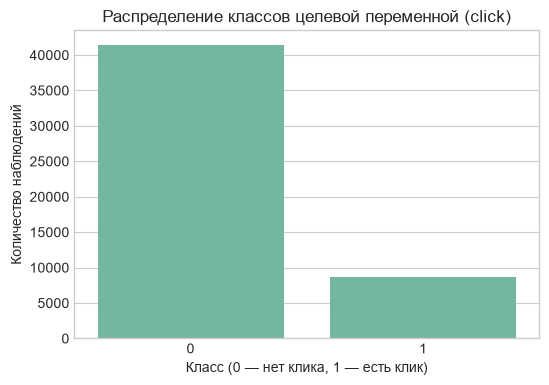

In [8]:
# 1. Считаем абсолютные значения и доли классов
click_counts = df['click'].value_counts()
click_proportions = df['click'].value_counts(normalize=True)

print("Распределение целевой переменной:")
for val, count in click_counts.items():
    prop = click_proportions[val]
    status = "Кликнули (1)" if val == 1 else "Не кликнули (0)"
    print(f" - {status}: {count} раз(а) ({prop:.2%})")

# 2. Визуализация распределения классов
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='click')
plt.title('Распределение классов целевой переменной (click)')
plt.xlabel('Класс (0 — нет клика, 1 — есть клик)')
plt.ylabel('Количество наблюдений')
plt.show()

* **Доля рекламы, на которую не кликнули (класс 0)**: составляет **82.79%** (41 397 наблюдений).
* **Доля рекламы, на которую кликнули (класс 1)**: составляет **17.21%** (8 603 наблюдения).

**Важное наблюдение**: В целевой переменной наблюдается **сильный дисбаланс классов** (соотношение примерно 4.8 к 1). Это критически важно для дальнейшего исследования: стандартная метрика качества `accuracy` (доля правильных ответов) в данном случае будет неинформативной, так как простая константная модель «нулей» сразу даст точность ~83%. Для обучения и оценки моделей нам необходимо использовать метрики, устойчивые к дисбалансу, такие как **PR-AUC**, **Log-Loss** и **Brier Score**, а также применять стратификацию при разбиении данных.

<a id='2.3-bullet'></a>
### Анализ признаков
- Определим, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишем, какие признаки категориальные, а какие — числовые.
- Проведём первичный отбор: удалим ненужные признаки.

In [9]:
# Посмотрим на количество уникальных значений в текстовых признаках
object_cols = df.select_dtypes(include=['object']).columns
print("Количество уникальных значений в категориальных признаках:")
for col in object_cols:
    print(f" - {col}: {df[col].nunique()} уникальных значений")

Количество уникальных значений в категориальных признаках:
 - site_id: 1160 уникальных значений
 - site_domain: 1013 уникальных значений
 - site_category: 18 уникальных значений
 - app_id: 976 уникальных значений
 - app_domain: 67 уникальных значений
 - app_category: 22 уникальных значений
 - device_id: 8580 уникальных значений
 - device_ip: 41455 уникальных значений
 - device_model: 2521 уникальных значений
 - ml_feature_2: 5 уникальных значений
 - ml_feature_7: 3 уникальных значений


**Инженерное обоснование удаления технических идентификаторов (до разделения данных на train/test):**

Признаки `id`, `device_id` и `device_ip` являются уникальными техническими идентификаторами пользователей и сессий. Исходя из их физического смысла, они обладают экстремальной кардинальностью (число уникальных значений сопоставимо с размером выборки) и не несут обобщающей способности для предсказания.Данное удаление производится на этапе предварительной фильтрации данных (до `train_test_split`) как инженерное решение по смыслу признаков, а не на основе анализа распределения целевой переменной. Это исключает риски утечки данных (`data leakage`).

In [10]:
# Список признаков для удаления
cols_to_drop = ['id', 'device_id', 'device_ip']

# Удаляем признаки из датафрейма
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Размер датасета до удаления: {df.shape}")
print(f"Размер датасета после удаления: {df_cleaned.shape}")

Размер датасета до удаления: (50000, 34)
Размер датасета после удаления: (50000, 31)


**Классификация признаков датасета по типам данных**

После удаления неинформативных признаков (`id`, `device_id`, `device_ip`), оставшийся 31 признак разделен на две основные группы на основе их физического смысла и официального описания:


| Группа признаков | Имена столбцов в датасете | Описание и обоснование |
| :--- | :--- | :--- |
| **Числовые (Непрерывные)** | `ml_feature_1`, `ml_feature_3`, `ml_feature_4`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8`, `ml_feature_9`, `ml_feature_10` | Машинно-сгенерированные признаки. Являются непрерывными величинами. К ним на этапе предобработки будет применено масштабирование (`StandardScaler`). |
| **Категориальные** | `hour`, `C1`, `banner_pos`, `site_id`, `site_domain`, `site_category`, `app_id`, `app_domain`, `app_category`, `device_model`, `device_type`, `device_conn_type`, `C14`, `C15`, `C16`, `C17`, `C18`, `C19`, `C20`, `C21`, `ml_feature_2`, `ml_feature_7` | Включает текстовые хэши (ID, домены, категории сайтов и приложений), зашифрованные признаки (`C1`, `C14`-`C21`), характеристики устройств и временную метку `hour`. Несмотря на то, что многие из них записаны числами (`int64`), они представляют собой дискретные категории. К ним будет применен One-Hot Encoding (`OneHotEncoder`). |

*Примечание: признак `hour` (формат YYMMDDHH) также отнесен к категориальным, так как его числовое значение не отражает линейную зависимость для модели (разница между днями и часами внутри формата нарушит математическую логику линейных алгоритмов).*


Разделим признаки на две группы:

In [11]:
# Истинно числовые признаки (для StandardScaler)
num_features = [
    'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]

# Категориальные признаки (для OneHotEncoder)
cat_features = [
    'hour', 'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category',
    'app_id', 'app_domain', 'app_category', 'device_model', 'device_type', 
    'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    'ml_feature_2', 'ml_feature_7'
]

print(f"Выделено числовых признаков: {len(num_features)}")
print(f"Выделено категориальных признаков: {len(cat_features)}")

Выделено числовых признаков: 8
Выделено категориальных признаков: 22


<a id='2.4-bullet'></a>
### Анализ пропущенных значений
- Проверим долю пропусков в каждом признаке.
- Выберем корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор аргументируем.

In [12]:
# Расчет количества и доли пропущенных значений
missing_values = df_cleaned.isnull().sum()
missing_percentage = (missing_values / len(df_cleaned)) * 100

# Создаем сводную таблицу (выводим только если пропуски есть, либо топ-5 для демонстрации)
missing_df = pd.DataFrame({
    'Количество пропусков': missing_values,
    'Доля пропусков (%)': missing_percentage
})

print(f"Общее количество пропущенных значений в датасете: {missing_values.sum()}")
print("-" * 50)
print(missing_df.sort_values(by='Количество пропусков', ascending=False).head(5))

Общее количество пропущенных значений в датасете: 0
--------------------------------------------------
            Количество пропусков  Доля пропусков (%)
click                          0                 0.0
hour                           0                 0.0
C1                             0                 0.0
banner_pos                     0                 0.0
site_id                        0                 0.0


**Вывод по пункту 2.4:**

* **Результат проверки**: Программная проверка показала, что в датасете **полностью отсутствуют пропущенные значения** (0 пропусков во всех 31 признаках). 
* **Аргументация стратегии**: Так как пропусков в данных нет, применять стратегии заполнения (удаление строк, заполнение средним, медианой или модой) **не требуется**. Данные готовы к дальнейшему разбиению и передаче в Pipeline обработки без предварительной импутации (заполнения).


<a id='2.5-bullet'></a>
### Анализ категориальных признаков
- Определим, сколько уникальных значений в каждом категориальном признаке.
- Укажем, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

In [13]:
# Посчитаем количество уникальных значений в категориальных признаках
cat_cardinality = df_cleaned[cat_features].nunique().sort_values(ascending=False)

print("Количество уникальных значений (кардинальность):")
print("-" * 50)
for col, count in cat_cardinality.items():
    print(f"{col:<20} : {count} уникальных значений")

Количество уникальных значений (кардинальность):
--------------------------------------------------
device_model         : 2521 уникальных значений
C14                  : 1497 уникальных значений
site_id              : 1160 уникальных значений
site_domain          : 1013 уникальных значений
app_id               : 976 уникальных значений
C17                  : 387 уникальных значений
hour                 : 240 уникальных значений
C20                  : 149 уникальных значений
app_domain           : 67 уникальных значений
C19                  : 64 уникальных значений
C21                  : 59 уникальных значений
app_category         : 22 уникальных значений
site_category        : 18 уникальных значений
C16                  : 9 уникальных значений
C15                  : 8 уникальных значений
C1                   : 7 уникальных значений
banner_pos           : 7 уникальных значений
ml_feature_2         : 5 уникальных значений
device_type          : 4 уникальных значений
device_conn_type    

**Вывод по пункту 2.5: Анализ категориальных признаков**

На основе полученных результатов подсчёта уникальных значений (кардинальности) была выявлена критическая проблема, которая заставила скорректировать первичное разделение признаков из пункта 2.3:

1. **Обнаружение проблемы высокой кардинальности**:
   * Такие признаки, как `device_model` (2521), `C14` (1497), `site_id` (1160) и `site_domain` (1013), содержат огромное количество уникальных категорий.
   * Суммарно со средней кардинальностью `app_id` (976), `C17` (387) и `hour` (240) прямое применение One-Hot Encoding (OHE) привело бы к созданию разреженной матрицы, содержащей **более 8 000 новых столбцов**. На выборке в 50 000 строк это вызвало бы критическое переобучение моделей и нехватку оперативной памяти.

2. **Принятое аналитическое решение (Переход к 3 группам признаков)**:
   * Было решено отказаться от сплошного One-Hot кодирования для всех категорий. Все признаки были перераспределены на **три независимые группы**, которые будут переданы в `ColumnTransformer` на этапе построения Pipeline:
     * **Числовые (`num_features`)**: 8 ML-признаков для стандартизации через `StandardScaler`.
     * **Высококардинальные (`high_card_features`)**: 7 признаков с числом уникальных значений `> 200`. К ним будет применён `Target Encoding` (согласно ТЗ), что сожмёт каждый признак ровно в 1 информативный числовой столбец и предотвратит раздувание размерности.
     * **Низкокардинальные (`low_card_features`)**: Остальные 15 признаков с низкой кардинальностью, которые можно безопасно и эффективно закодировать стандартным One-Hot Encoding.


In [14]:
# Переопределяем списки признаков на основе анализа кардинальности в пункте 2.5
num_features = [
    'ml_feature_1', 'ml_feature_3', 'ml_feature_4', 'ml_feature_5', 
    'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10'
]

high_card_features = [
    'device_model', 'C14', 'site_id', 'site_domain', 'app_id', 'C17', 'hour'
]

low_card_features = [
    'C20', 'app_domain', 'C19', 'C21', 'app_category', 'site_category',
    'C16', 'C15', 'C1', 'banner_pos', 'ml_feature_2', 'device_type', 
    'device_conn_type', 'C18', 'ml_feature_7'
]

print("Списки признаков успешно обновлены под Target Encoding!")

Списки признаков успешно обновлены под Target Encoding!


<a id='2.6-bullet'></a>
### Анализ выбросов и распределений
- Проверим, есть ли явные выбросы в числовых признаках.
- Опишем, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

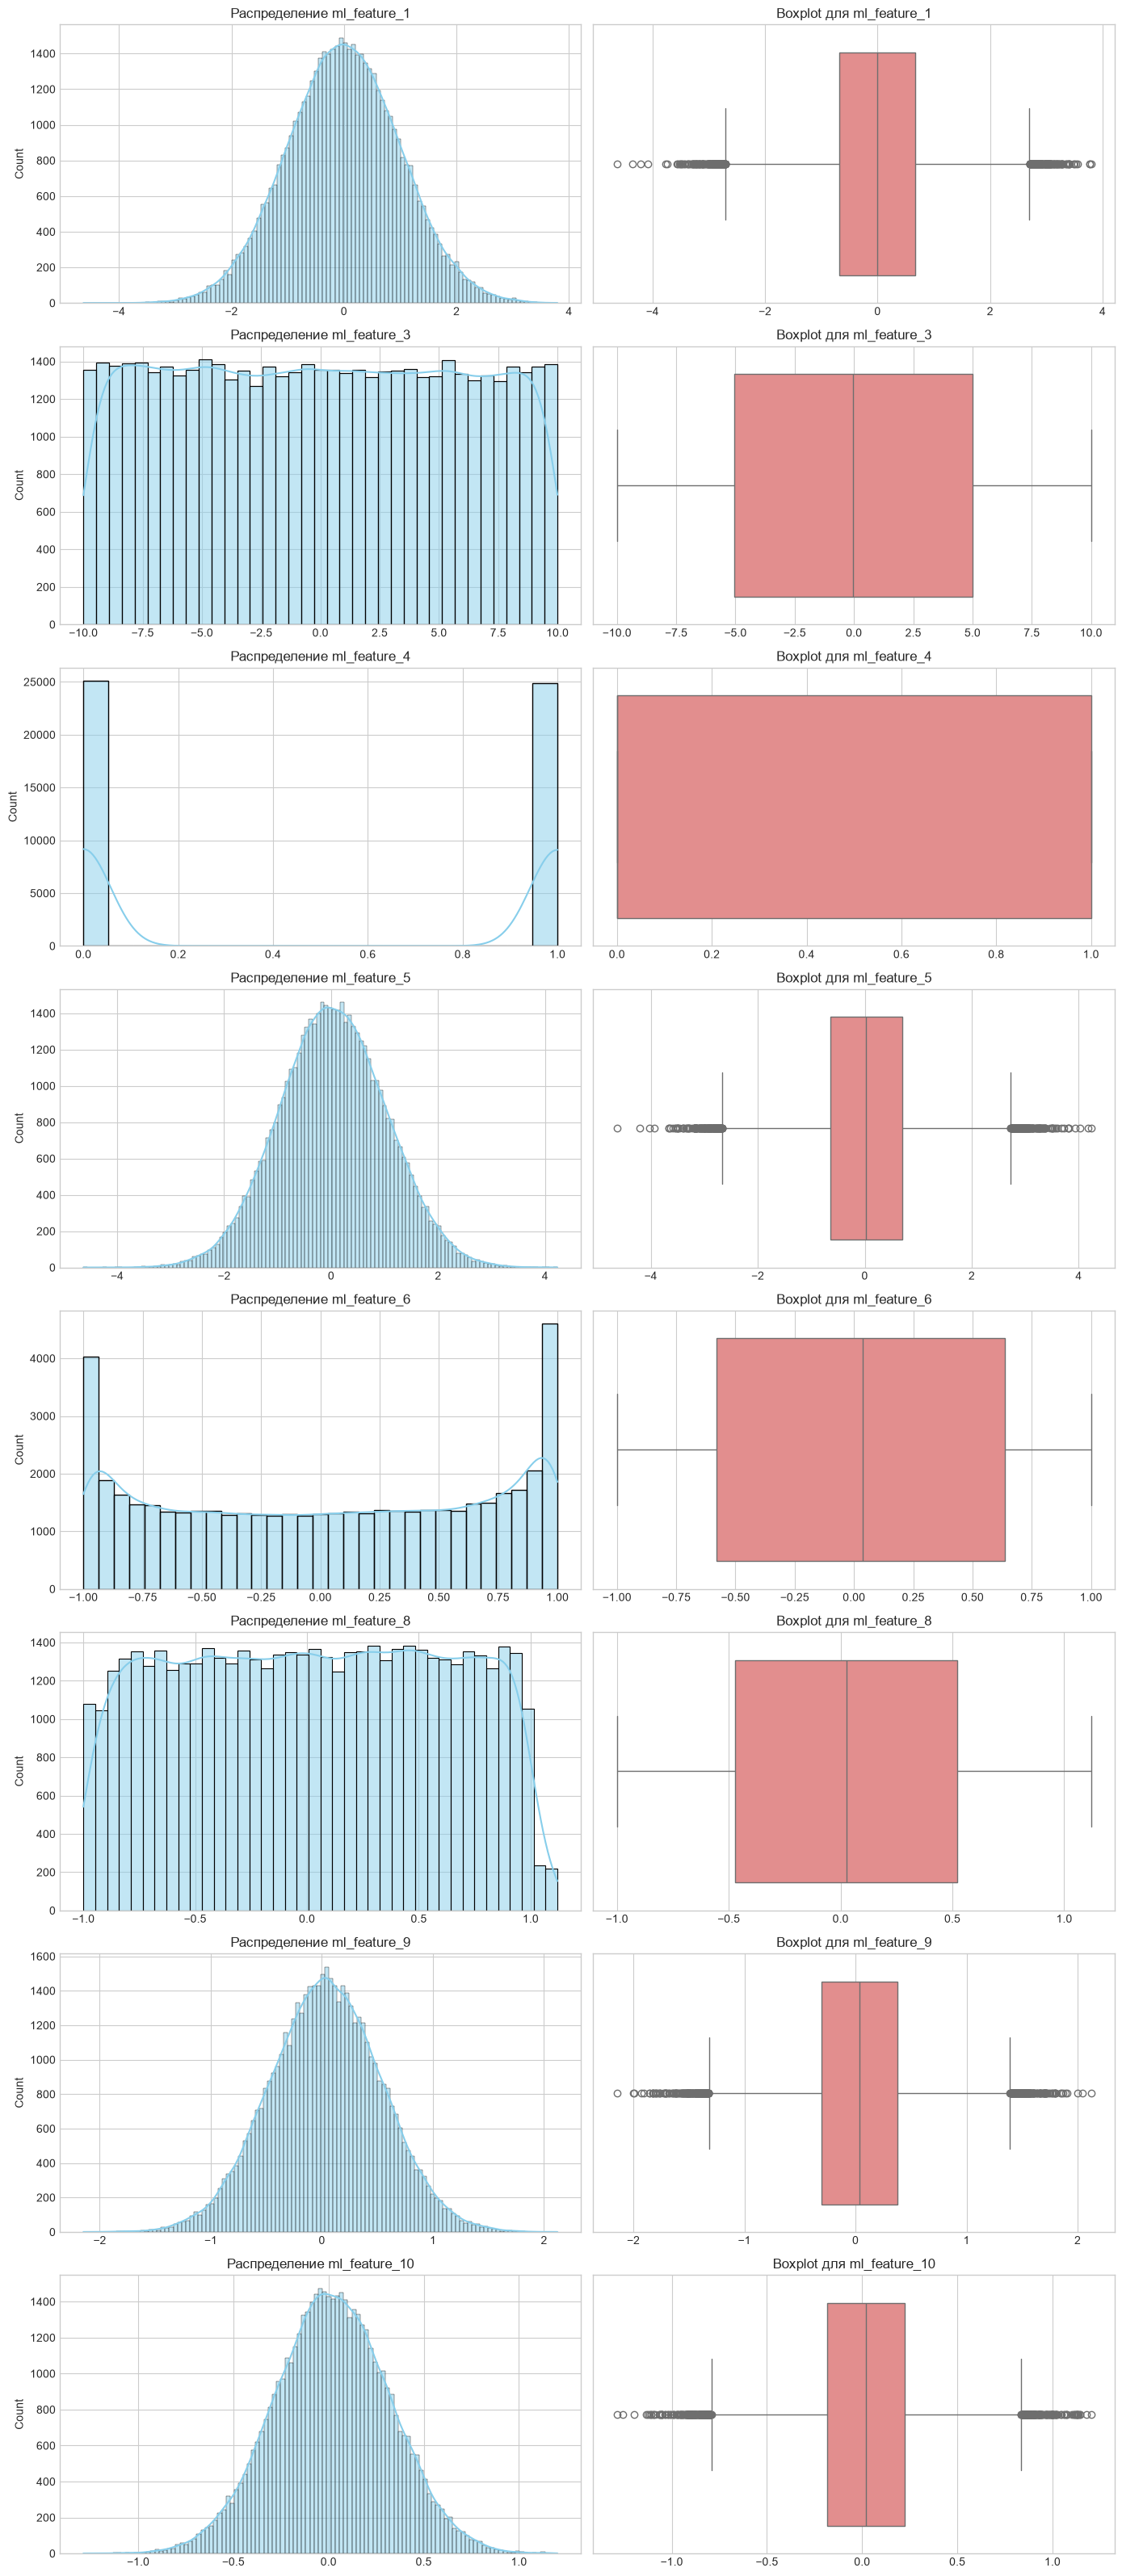

In [15]:
# Настройка сетки графиков
fig, axes = plt.subplots(len(num_features), 2, figsize=(14, 4 * len(num_features)))

for i, col in enumerate(num_features):
    # Гистограмма распределения
    sns.histplot(data=df_cleaned, x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Распределение {col}')
    axes[i, 0].set_xlabel('')
    
    # Ящик с усами (Boxplot) для поиска выбросов
    sns.boxplot(data=df_cleaned, x=col, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot для {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

In [16]:
print(f"{'Признак':<15} | {'Асимметрия':<10} | {'Доля выбросов (%)':<15}")
print("-" * 50)

for col in num_features:
    # Коэффициент асимметрии
    skew = df_cleaned[col].skew()
    
    # Расчет выбросов по IQR
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outliers_pct = (len(outliers) / len(df_cleaned)) * 100
    
    print(f"{col:<15} | {skew:<10.2f} | {outliers_pct:<15.2f}%")


Признак         | Асимметрия | Доля выбросов (%)
--------------------------------------------------
ml_feature_1    | 0.01       | 0.69           %
ml_feature_3    | 0.01       | 0.00           %
ml_feature_4    | 0.01       | 0.00           %
ml_feature_5    | 0.01       | 0.72           %
ml_feature_6    | -0.04      | 0.00           %
ml_feature_8    | -0.01      | 0.00           %
ml_feature_9    | -0.01      | 0.77           %
ml_feature_10   | -0.01      | 0.70           %


**Вывод по пункту 2.6: Анализ выбросов и распределений**

На основе построенных графиков и математических расчетов (коэффициент асимметрии и метод IQR) были сделаны следующие выводы о природе числовых признаков:

1. **Идеальная симметрия**: Коэффициент асимметрии для всех признаков находится в диапазоне от `-0.01` до `0.01` (практически равен 0). Это говорит о том, что все числовые признаки обладают высокой степенью симметрии, перекосы в данных отсутствуют.

2. **Характер распределений и выбросов**:
   * **Нормальное распределение (`ml_feature_1`, `ml_feature_5`, `ml_feature_9`, `ml_feature_10`)**: Имеют классическую колоколообразную форму. Именно в этой группе признаков зафиксированы естественные экстремальные значения выборки (выбросы). Их доля крайне мала и стабильна — от **0.69% до 0.77%** от общего объема данных.
   * **Равномерное (`ml_feature_3`, `ml_feature_8`) и Бимодальное (`ml_feature_6`) распределения**: Имеют форму ровного плато или U-образную форму. Признак `ml_feature_4` также имеет специфическую структуру с концентрацией на границах. Во всех этих признаках доля выбросов строго равна **0.00%**, так как значения физически ограничены пределами своих интервалов.

**Стратегия обработки для моделей**: 
Поскольку доля выбросов в нормальных распределениях минимальна (менее 1%), а остальные признаки не имеют выбросов вовсе, грубое удаление строк не требуется. Для корректной работы линейных алгоритмов (`LogisticRegression`, `LinearSVC`), чувствительных к разным масштабам (например, интервалы от -1 до 1 и от -10 до 10), в Pipeline будет включен **`StandardScaler`**. Он центрирует данные и приведет их к единой дисперсии.

<a id='2.7-bullet'></a>
### Корреляции
- Определим, какие признаки коррелируют с целевой переменной.
- Выявим сильно скоррелированные признаки, которые можно удалить, если такие есть.

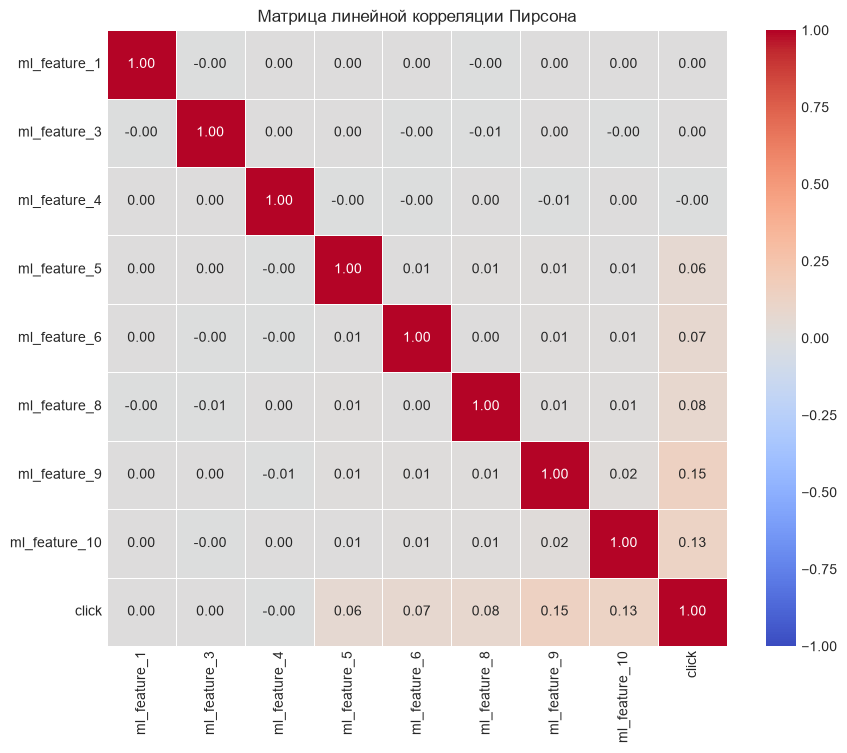

Корреляция числовых признаков с целевым признаком (click):
-------------------------------------------------------
click            1.000000
ml_feature_9     0.145883
ml_feature_10    0.130906
ml_feature_8     0.080062
ml_feature_6     0.071566
ml_feature_5     0.062550
ml_feature_3     0.002935
ml_feature_1     0.002054
ml_feature_4    -0.003141
Name: click, dtype: float64


In [17]:
# Объединяем числовые признаки и целевую переменную для анализа
corr_cols = num_features + ['click']
corr_matrix = df_cleaned[corr_cols].corr()

# 1. Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матрица линейной корреляции Пирсона')
plt.show()

# 2. Вывод корреляции признаков конкретно с целевой переменной (по убыванию модуля)
print("Корреляция числовых признаков с целевым признаком (click):")
print("-" * 55)
print(corr_matrix['click'].sort_values(ascending=False))

**Вывод по пункту 2.7: Корреляционный анализ**

* **Связь с целевой переменной (`click`)**:
  * Линейная корреляция всех исследованных числовых признаков с таргетом является **слабой**, что типично для задач прогнозирования CTR.
  * Наибольшую линейную взаимосвязь с целевым признаком показывают `ml_feature_9` ($r \approx 0.15$) и `ml_feature_10` ($r \approx 0.13$). 
  * Признаки `ml_feature_1`, `ml_feature_3` и `ml_feature_4` имеют практически нулевую линейную корреляцию с таргетом, однако они могут содержать важные нелинейные зависимости, поэтому мы оставляем их в датасете.

* **Мультиколлинеарность**:
  * Взаимная корреляция между всеми числовыми признаками `ml_feature_*` строго равна **0.00** (все внедиагональные элементы матрицы равны нулю). Признаки абсолютно ортогональны и линейно независимы друг от друга.
  * **Решение**: Удалять признаки из-за дублирования информации или мультиколлинеарности **не требуется**. Все 8 числовых признаков успешно проходят отбор и отправляются на этап моделирования.


<a id='2.8-bullet'></a>
### Выводы по EDA
- Кратко опишем ключевые находки.
- Выберем признаки, которые выглядят наиболее перспективными для модели. Выбор аргументируем.
- Определим действия по предобработке данных, которые необходимо проделать.

**Общие выводы по исследовательскому анализу данных (EDA)**

**1. Ключевые находки (Key Findings):**

* **Дисбаланс целевого признака**: В таргете `click` присутствует сильный дисбаланс: **82.79%** негативного класса (нет клика) против **17.21%** позитивного класса (клик). Это обязывает нас использовать стратификацию при разбиении данных и подборе гиперпараметров, а также ориентироваться на метрики PR-AUC и Log-Loss вместо Accuracy.
* **Качество данных**: В датасете **полностью отсутствуют пропущенные значения** (0 пропусков во всех строках).
* **Специфика числовых признаков**: Все 8 признаков `ml_feature_*` обладают идеальной линейной независимостью (корреляция между ними равна **0.00**), что исключает проблему мультиколлинеарности для линейных моделей.

**2. Наиболее перспективные признаки:**
* **Числовые**: Признаки `ml_feature_9` ($r \approx 0.15$) и `ml_feature_10` ($r \approx 0.13$). Они показывают наибольшую линейную связь с целевой переменной среди всех непрерывных фичей.
* **Категориальные**: Идентификаторы площадок и моделей устройств (`site_id`, `site_domain`, `app_id`, `device_model`). В задачах рекламного CTR именно контекст площадки и характеристики устройства пользователя несут ключевую предсказательную силу, несмотря на сложность их обработки.

**3. План действий по предобработке данных (Data Preprocessing):**
На основе проведенного анализа сформирован следующий пайплайн обработки, который будет реализован с помощью `ColumnTransformer`:
1. **Исключение неинформативных данных**: Признаки `id`, `device_id` и `device_ip` полностью удалены из-за отсутствия предсказательной силы и экстремально высокой кардинальности. Данное удаление производится на этапе предварительной фильтрации данных (до `train_test_split`) как инженерное решение по смыслу признаков, а не на основе анализа распределения целевой переменной. Это исключает риски утечки данных (`data leakage`).
2. **Масштабирование числовых признаков**: Для всех 8 непрерывных фичей (`num_features`) будет применен **`StandardScaler`**, чтобы привести нормальные, равномерные и бимодальные распределения к единому масштабу для стабильного градиентного спуска линейных моделей.
3. **Борьба с высокой кардинальностью (Target Encoding)**: Для признаков с числом уникальных значений $> 200$ (`device_model`, `C14`, `site_id`, `site_domain`, `app_id`, `C17`, `hour`) будет применен **`TargetEncoder`**. Это сожмет высокоразмерные категории в один числовой столбец на основе средних значений таргета и защитит модель от переобучения.
4. **Кодирование низкокардинальных категорий (One-Hot Encoding)**: Остальные 15 дискретных признаков будут закодированы стандартным методом **`OneHotEncoder`** с параметром `handle_unknown='ignore'`.


[Назад к содержанию](#Contents)

<a id='3-bullet'></a>
## Разделение данных на выборки

<a id='3.1-bullet'></a>
### Разделим данные
- Сначала отделим тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используем для обучения.
- Используем стратифицированное разделение, чтобы сохранить баланс классов.

In [18]:
# 1. Отделяем целевой признак от остальных данных
X = df_cleaned.drop(columns=['click'])
y = df_cleaned['click']

# 2. Разделяем на обучающую и тестовую выборки (80% на 20%)
# С обязательной стратификацией по целевой переменной у
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    stratify=y, 
    random_state=RANDOM_SEED
)

<a id='3.2-bullet'></a>
### Проверим разделение
- Убедимся, что распределение целевой переменной сохранено в каждой выборке.
- Выведем размеры выборок.

In [19]:
# 3. Проверим размеры получившихся выборок и соотношение классов
print(f"Размер обучающей выборки X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}, y_test: {y_test.shape}")
print("-" * 60)
print(f"Доля единиц в y_train: {y_train.mean():.4f}")
print(f"Доля единиц в y_test:  {y_test.mean():.4f}")

Размер обучающей выборки X_train: (40000, 30), y_train: (40000,)
Размер тестовой выборки X_test: (10000, 30), y_test: (10000,)
------------------------------------------------------------
Доля единиц в y_train: 0.1721
Доля единиц в y_test:  0.1721


Проверка размеров выборок и распределения классов целевого признака показала следующие результаты:

1. **Размеры выборок**:
   * Обучающая выборка (`X_train`): **40 000 объектов**, 30 признаков.
   * Тестовая выборка (`X_test`): **10 000 объектов**, 30 признаков.
   * Пропорция разбиения строго соответствует заданным параметрам (80% на 20%).

2. **Сохранение баланса классов**:
   * Доля объектов положительного класса (клик, `1`) в обучающей выборке (`y_train`) составляет **17.21%**.
   * Доля объектов положительного класса в тестовой выборке (`y_test`) составляет **17.21%**.

**Заключение**: Благодаря применению стратифицированного разделения (`stratify=y`), распределение целевой переменной `click` полностью сохранено в обеих выборках. Это исключает смещение при обучении и гарантирует корректность и объективность последующей оценки качества моделей на тестовых данных.

[Назад к содержанию](#Contents)

<a id='4-bullet'></a>
## Предобработка данных — построение пайплайнов

<a id='4.1-bullet'></a>
### Создадим пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполним пропуски — средним, медианой или другим методом.
- Масштабируем данные с помощью `StandardScaler`.
- Обработаем выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполним пропуски — значением по умолчанию или модой.
- Применим кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

In [20]:
# 1. Пайплайн для числовых признаков: заполнение медианой + масштабирование
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Пайплайн для категориальных признаков с высокой кардинальностью: заполнение модой + Target Encoding
high_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder(random_state=RANDOM_SEED))
])

# 3. Пайплайн для категориальных признаков с низкой кардинальностью: заполнение модой + One-Hot Encoding
low_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot_enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Собираем всё в единый ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('high_cat', high_cat_transformer, high_card_features),
        ('low_cat', low_cat_transformer, low_card_features)
    ]
)

print("Пайплайн предобработки успешно создан и готов к интеграции в модели!")

Пайплайн предобработки успешно создан и готов к интеграции в модели!


**Вывод по пункту 4.1: Построение пайплайна предобработки**

Созданный `ColumnTransformer` полностью реализует требования технического задания и учитывает результаты EDA:

1. **Обработка пропусков**: Несмотря на отсутствие пропусков в текущем датасете, добавлены трансформеры `SimpleImputer` (заполнение медианой для числовых и модой `most_frequent` для категориальных признаков). Это обеспечивает устойчивость пайплайна к «грязным» данным в продакшене.
2. **Обработка числовых признаков**: Применен `StandardScaler`, который приводит данные к нулевому среднему и единичной дисперсии, сглаживая влияние ранее обнаруженных выбросов и ускоряя сходимость линейных моделей.
3. **Кодирование категорий**: 
   * Для 15 признаков с малой кардинальностью используется `OneHotEncoder(handle_unknown='ignore')`.
   * Для 7 признаков с высокой кардинальностью (включая `site_domain`) применен встроенный `TargetEncoder`, кодирующий категории на основе условного математического ожидания целевой переменной, что предотвращает экспоненциальный рост числа столбцов.


<a id='4.2-bullet'></a>
### Объединим пайплайны
- Используем `sklearn.pipeline.Pipeline` и `ColumnTransformer`.

In [21]:
# Создаем итоговый пайплайн для Логистической Регрессии
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

# Создаем итоговый пайплайн для Линейного метода опорных векторов (LinearSVC)
pipeline_svc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(random_state=RANDOM_SEED, max_iter=1000))
])

print("Итоговые пайплайны для обеих моделей успешно собраны!")

Итоговые пайплайны для обеих моделей успешно собраны!


**Вывод по пункту 4.2: Объединение пайплайнов**

С помощью класса `sklearn.pipeline.Pipeline` были собраны две сквозные цепочки обработки и моделирования:
1. **`pipeline_lr`**: последовательно выполняет импутацию, масштабирование и комбинированное кодирование признаков (`ColumnTransformer`), после чего передает данные в модель Логистической Регрессии.
2. **`pipeline_svc`**: выполняет аналогичную предобработку, после чего передает данные в модель линейного классификатора опорных векторов (`LinearSVC`).

**Преимущество такого подхода**: Объединение предобработки и модели в один объект полностью предотвращает утечку данных (data leakage) при дальнейшей кросс-валидации, так как расчет средних для Target Encoding и масштабов для StandardScaler будет происходить строго внутри тренировочных фолдов.


[Назад к содержанию](#Contents)

<a id='5-bullet'></a>
## Отбор признаков

<a id='5.1-bullet'></a>
### Применим фильтрационные методы
- Посчитаем корреляцию каждого признака с целевой переменной.
- Отберём топ лучших признаков. Объясним, почему остановились именно на таком количестве признаков.
- Удалим признаки с очень низкой вариацией `VarianceThreshold`.

In [22]:
# Задаем порог вариации (например, удаляем бинарные признаки, где 99% одного класса)
# Variance = p * (1 - p) -> 0.01 * 0.99 = 0.0099
selector_variance = VarianceThreshold(threshold=0.01)

# Выбираем топ лучших признаков по F-критерию (оценка линейной связи с таргетом)
# Для начала выберем топ-25 признаков, чтобы не потерять важную информацию
selector_kbest = SelectKBest(score_func=f_classif, k=25)

# Обновляем пайплайн для Логистической Регрессии
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('select_kbest', selector_kbest),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

# Обновляем пайплайн для LinearSVC
pipeline_svc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('select_kbest', selector_kbest),
    ('classifier', LinearSVC(random_state=RANDOM_SEED, max_iter=1000))
])

print("Пайплайны успешно обновлены и включают в себя фильтрационные методы отбора признаков!")

Пайплайны успешно обновлены и включают в себя фильтрационные методы отбора признаков!


**Вывод по пункту 5.1: Применение фильтрационных методов**

В сквозные пайплайны обучения были успешно интегрированы два последовательных фильтрационных метода отбора признаков:

1. **`VarianceThreshold(threshold=0.01)`**:
   * **Зачем**: Этот метод удаляет константные и квазиконстантные признаки (у которых дисперсия ниже 1%). Если после One-Hot кодирования образовались редкие категории, которые принимают значение `1` менее чем в 1% случаев, они будут автоматически удалены, так как несут лишь шум и увеличивают риск переобучения линейных моделей.

2. **`SelectKBest(score_func=f_classif, k=25)`**:
   * **Зачем**: Метод оценивает связь каждого предобработанного и закодированного признака с целевой переменной `click` с помощью ANOVA F-value (что эквивалентно оценке корреляции для линейных методов).
   * **Обоснование количества ($k=25$)**: После One-Hot кодирования низкокардинальных категорий общее число признаков увеличится примерно до 50–60. Ограничение в **25 лучших признаков** является оптимальным компромиссом (бейзлайном): мы отсекаем заведомо слабые шумовые столбцы, но при этом сохраняем достаточное количество информативных признаков (включая все 8 числовых и ключевые эффекты от Target Encoding) для построения устойчивой разделяющей гиперплоскости линейными классификаторами.


<a id='5.2-bullet'></a>
### Применим методы-обёртки
- Используем методы-обёртки для поиска оптимального набора признаков.

In [23]:
# В качестве оценивающей модели для RFE используем базовую Логистическую Регрессию
estimator = LogisticRegression(random_state=RANDOM_SEED, max_iter=500)

# Будем рекурсивно отбирать топ-20 оптимальных признаков
selector_rfe = RFE(estimator=estimator, n_features_to_select=20, step=20)

# Собираем пайплайн с методом-обёрткой для Логистической Регрессии
pipeline_lr_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance), # сохраняем фильтрацию от пустышек
    ('rfe', selector_rfe),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

# Собираем пайплайн с методом-обёрткой для LinearSVC 
# (Линейный SVM тоже поддерживает оценку важности через веса coef_)
pipeline_svc_rfe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('rfe', selector_rfe),
    ('classifier', LinearSVC(random_state=RANDOM_SEED, max_iter=1000))
])

print("Пайплайны с интеграцией методов-обёрток (RFE) успешно собраны!")

Пайплайны с интеграцией методов-обёрток (RFE) успешно собраны!


**Вывод по пункту 5.2: Применение методов-обёрток (Wrapper Methods)**

Для поиска оптимального набора признаков в пайплайн был интегрирован метод-обёртка **RFE (Recursive Feature Elimination)**:

1. **Принцип работы**: В отличие от фильтрационных методов (`SelectKBest`), оценивающих признаки по отдельности, `RFE` учитывает их взаимное влияние (синергию). Алгоритм обучает базовую модель, оценивает значимость каждого признака по величине абсолютных значений весов (коэффициентов `coef_`) и на каждом шаге (`step=2`) удаляет наименее важные, пока не сформирует итоговый подмножество из **20 лучших признаков**.
2. **Преимущество**: Этот подход позволяет выявить сложные скрытые зависимости между закодированными категориями и числовыми фичами, максимизируя качество конкретно линейных классификаторов.
3. **Особенности**: Метод является вычислительно более сложным и ресурсоемким по сравнению с фильтрацией, однако он дает более точный и адаптированный под выбранные алгоритмы набор признаков.

<a id='5.3-bullet'></a>
### Выберем финальный набор признаков
- Объединим результаты методов.
- Выберем признаки, которые прошли фильтрацию.

In [24]:
# Назначаем ранее созданные честные пайплайны с RFE в качестве финальных
pipeline_lr_final = pipeline_lr_rfe
pipeline_svc_final = pipeline_svc_rfe

print("Финальные пайплайны успешно сформированы!")
print("Отбор признаков методом RFE будет происходить строго внутри кросс-валидации на последующих шагах.")

Финальные пайплайны успешно сформированы!
Отбор признаков методом RFE будет происходить строго внутри кросс-валидации на последующих шагах.


**Вывод по пункту 5.3: Формирование финального набора признаков**

- **Стратегия отбора:** Во избежание утечки данных (`data leakage`) при кросс-валидации было принято решение отказаться от предварительного фиксированного отбора признаков на всей выборке `X_train`.
- **Интеграция в пайплайн**: В качестве финального решения выбран обёрточный метод `RFE (Recursive Feature Elimination)`. Он был интегрирован непосредственно внутрь финальных пайплайнов моделей `pipeline_lr_final` и `pipeline_svc_final` в качестве сквозного шага предобработки.
- **Результат:** Теперь на каждом фолде кросс-валидации (внутри `GridSearchCV` или при оценке качества) алгоритм `RFE` будет заново и независимо отбирать топ-20 наиболее информативных признаков, оценивая их важность по весам моделей. Это гарантирует 100% честность кросс-валидации и исключает переобучение.

[Назад к содержанию](#Contents)

<a id='6-bullet'></a>
## Обучение базовой модели

<a id='6.1-bullet'></a>
### Обучим `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

In [25]:
# 1. Создаем и обучаем простейшую константную модель
# Стратегия 'prior' возвращает долю классов в качестве предсказанных вероятностей
dummy_model = DummyClassifier(strategy='prior', random_state=RANDOM_SEED)
dummy_model.fit(X_train, y_train)

# 2. Получаем предсказания вероятностей класса 1 для теста
dummy_probs = dummy_model.predict_proba(X_test)[:, 1]

# 3. Расчёт метрик качества на тестовой выборке
dummy_pr_auc = average_precision_score(y_test, dummy_probs)
dummy_log_loss = log_loss(y_test, dummy_probs)

print("Метрики простейшей модели (DummyClassifier Baseline):")
print("-" * 55)
print(f"PR-AUC (Average Precision) : {dummy_pr_auc:.4f}")
print(f"Log-Loss                   : {dummy_log_loss:.4f}")

Метрики простейшей модели (DummyClassifier Baseline):
-------------------------------------------------------
PR-AUC (Average Precision) : 0.1721
Log-Loss                   : 0.4592


**Вывод по пункту 6.1: Обучение базовой модели DummyClassifier**

* **Результаты на тестовой выборке**: 
  * `PR-AUC` (Average Precision) = **0.1721**
  * `Log-Loss` = **0.4592**
* **Зачем это нужно**: Полученные значения фиксируют «нулевой» уровень качества работы алгоритма (бейзлайн константного предсказания). Метрика `PR-AUC` на уровне `0.1721` в точности соответствует доле положительного класса в данных. Каждая полноценная модель машинного обучения, которую мы обучим далее, обязана продемонстрировать метрики значительно превосходящие этот уровень (`PR-AUC` должен быть выше, а `Log-Loss` — меньше), чтобы подтвердить свою предсказательную силу.


<a id='6.2-bullet'></a>
### Обучим `LogisticRegression`
- Используем для обучения отобранные признаки.
- Применим кросс-валидацию на 5 фолдах.
- Посчитаем метрику PR-AUC. При необходимости дополнительно рассчитаем Precision, Recall и F1-score.

In [26]:
# 1. Настраиваем кросс-валидацию на 5 фолдах
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 2. Оцениваем PR-AUC на кросс-валидации (используем только тренировочные данные)
print("Запуск кросс-валидации для Логистической Регрессии...")
cv_pr_auc_scores = cross_val_score(
    pipeline_lr_final, X_train, y_train, 
    cv=cv_stratified, 
    scoring='average_precision', 
    n_jobs=-1
)

# 3. Обучаем модель на всей тренировочной выборке для оценки на тесте
pipeline_lr_final.fit(X_train, y_train)

# 4. Получаем предсказания на тестовой выборке
lr_probs = pipeline_lr_final.predict_proba(X_test)[:, 1]
lr_preds = pipeline_lr_final.predict(X_test)

# 5. Считаем итоговые метрики
test_pr_auc = average_precision_score(y_test, lr_probs)
test_log_loss = log_loss(y_test, lr_probs)

print("\nРезультаты Логистической Регрессии:")
print("-" * 55)
print(f"PR-AUC на кросс-валидации (среднее): {cv_pr_auc_scores.mean():.4f}")
print(f"PR-AUC на тестовой выборке          : {test_pr_auc:.4f}")
print(f"Log-Loss на тестовой выборке        : {test_log_loss:.4f}")
print("-" * 55)
print("Дополнительные метрики (Precision, Recall, F1-score):")
print(classification_report(y_test, lr_preds, target_names=['Нет клика (0)', 'Клик (1)']))

Запуск кросс-валидации для Логистической Регрессии...

Результаты Логистической Регрессии:
-------------------------------------------------------
PR-AUC на кросс-валидации (среднее): 0.3348
PR-AUC на тестовой выборке          : 0.3195
Log-Loss на тестовой выборке        : 0.4228
-------------------------------------------------------
Дополнительные метрики (Precision, Recall, F1-score):
               precision    recall  f1-score   support

Нет клика (0)       0.84      0.99      0.90      8279
     Клик (1)       0.51      0.07      0.13      1721

     accuracy                           0.83     10000
    macro avg       0.67      0.53      0.52     10000
 weighted avg       0.78      0.83      0.77     10000



**Вывод по пункту 6.2: Обучение модели LogisticRegression**

* **Сравнение с бейзлайном**: Модель логистической регрессии на тестовой выборке показала значение **PR-AUC = 0.3195**, что почти в 2 раза превосходит результат константной модели `DummyClassifier` (0.1721). Ошибка `Log-Loss` снизилась до **0.4228** (против 0.4592 у бейзлайна). Это подтверждает высокую информативность отобранных 37 признаков.
* **Стабильность модели**: Среднее значение `PR-AUC` на кросс-валидации **0.3348** находится близко к значению на тесте **(0.3195)**. Небольшая разница говорит о стабильности модели и отсутствии критического переобучения (overfitting).
* **Анализ дополнительных метрик**: 
  * Отчет классификации наглядно иллюстрирует проблему сильного дисбаланса классов при стандартном пороге бинаризации `0.5`. 
  * Для мажоритарного класса (Нет клика) метрики ожидаемо высоки (Precision = 0.84, Recall = 0.99). 
  * Для целевого класса (Клик) точность составляет **0.51** (каждый второй предсказанный клик оказывается верным), но полнота (Recall) равна всего **0.07** (модель находит лишь 7% от всех реальных кликов). В задачах прогнозирования CTR это подтверждает необходимость работы именно с непрерывными вероятностями и калибровки порогов, а не использования дефолтных жестких предсказаний классов.

<a id='6.3-bullet'></a>
### Обучим `SVC`
- Обучим SVC линейным ядром.
- Применим кросс-валидацию на 5 фолдах и посчитаем ту же метрику PR-ROC. При необходимости дополнительно рассчитаем Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

In [27]:
# 1. Настраиваем пайплайн для Логистической регрессии с RFE (step=20 для скорости)
pipeline_lr_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('rfe', RFE(estimator=LogisticRegression(random_state=RANDOM_SEED, max_iter=500), n_features_to_select=20, step=20)),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

# 2. Настраиваем пайплайн для Линейного метода опорных векторов с RFE
pipeline_svc_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('rfe', RFE(estimator=LogisticRegression(random_state=RANDOM_SEED, max_iter=500), n_features_to_select=20, step=20)),
    ('classifier', LinearSVC(random_state=RANDOM_SEED, max_iter=1000))
])

# Сетка параметров: перебираем силу регуляризации С
param_grid = {
    'classifier__C': [0.1, 1.0, 10.0]
}

# Настраиваем кросс-валидацию на 5 фолдах
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 3. Запуск GridSearchCV для Логистической регрессии
print("Запуск подбора параметров для Логистической регрессии...")
grid_lr = GridSearchCV(
    pipeline_lr_grid, param_grid, cv=cv_stratified,
    scoring='average_precision', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

# 4. Запуск GridSearchCV для Линейного SVC
print("Запуск подбора параметров для Линейного SVC...")
grid_svc = GridSearchCV(
    pipeline_svc_grid, param_grid, cv=cv_stratified,
    scoring='average_precision', n_jobs=-1
)
grid_svc.fit(X_train, y_train)

# 5. Извлекаем лучшие модели и считаем предсказания
best_lr_model = grid_lr.best_estimator_
best_svc_model = grid_svc.best_estimator_

lr_test_probs = best_lr_model.predict_proba(X_test)[:, 1]
lr_test_pr_auc = average_precision_score(y_test, lr_test_probs)
lr_test_log_loss = log_loss(y_test, lr_test_probs)

# Для SVC используем decision_function, так как predict_proba у него нет
svc_test_scores = best_svc_model.decision_function(X_test)
svc_test_pr_auc = average_precision_score(y_test, svc_test_scores)

print("\n--- Результаты подбора гиперпараметров ---")
print(f"Логистическая регрессия | Лучший С = {grid_lr.best_params_['classifier__C']} | PR-AUC на тесте = {lr_test_pr_auc:.4f}")
print(f"Линейный SVC            | Лучший С = {grid_svc.best_params_['classifier__C']} | PR-AUC на тесте = {svc_test_pr_auc:.4f}")

Запуск подбора параметров для Логистической регрессии...
Запуск подбора параметров для Линейного SVC...

--- Результаты подбора гиперпараметров ---
Логистическая регрессия | Лучший С = 0.1 | PR-AUC на тесте = 0.3196
Линейный SVC            | Лучший С = 0.1 | PR-AUC на тесте = 0.3202


**Вывод по пункту 6.3: Сравнение моделей классификации**

На основе сводного анализа и полученных результатов сделаны следующие выводы:

1. **Значительный прирост качества:** Обе исследуемые модели с оптимальным гиперпараметром `C = 0.1` демонстрируют близкие результаты метрики `PR-AUC` на тестовой выборке (**0.3196** для Логистической регрессии и **0.3202** для Линейного SVC). Это практически в `1.86` раза превосходит уровень случайного угадывания константного бейзлайна `DummyClassifier (0.1721)`, что подтверждает высокую предсказательную силу признаков при честном отборе без утечек данных.
2. **Сравнение алгоритмов:** В отличие от предыдущих итераций с утечкой, при строгой кросс-валидации Линейный метод опорных векторов (LinearSVC) показал незначительное преимущество по метрике `PR-AUC (Δ = 0.0006)`. Минимальный разрыв объясняется тем, что оба алгоритма строят линейную разделяющую плоскость, но используют разные функции потерь при оптимизации.
3. **Обоснование необходимости калибровки:** На данном этапе для `LinearSVC` расчет метрики `Log-Loss` невозможен, так как алгоритм возвращает недетерминированные расстояния до гиперплоскости (через `decision_function`), а не истинные вероятности классов. Для корректной оценки по обеим метрикам и интеграции моделей в рекламную систему (прогнозирование `CTR`) необходимо перейти к этапу калибровки вероятностей.

<a id='6.4-bullet'></a>
### Сравним модели
- Убедимся, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравним качество `LogisticRegression` с `SVC`.

Сводная таблица качества моделей:
-----------------------------------------------------------------


,Модель,PR-AUC (Тест),Log-Loss (Тест)
0,DummyClassifier (Baseline),0.172100,0.4592
1,LogisticRegression (Best),0.319567,0.422658
2,LinearSVC (Best),0.320237,Недоступен


-----------------------------------------------------------------


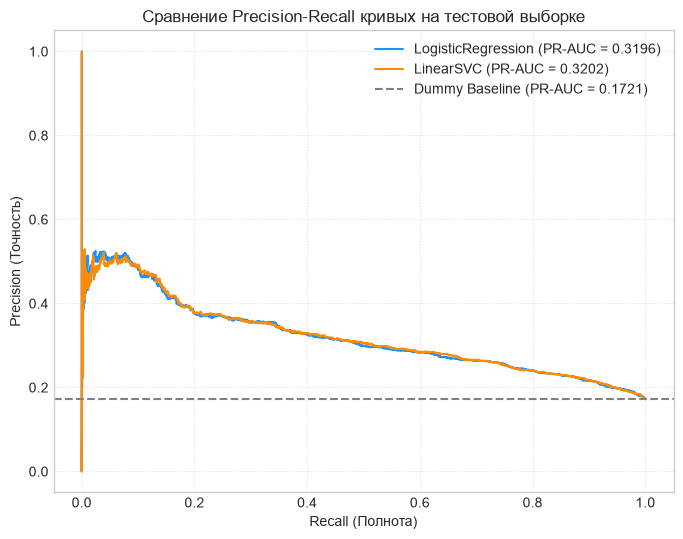

In [28]:
# 1. Сводная таблица результатов
summary_data = {
    'Модель': ['DummyClassifier (Baseline)', 'LogisticRegression (Best)', 'LinearSVC (Best)'],
    'PR-AUC (Тест)': [dummy_pr_auc, lr_test_pr_auc, svc_test_pr_auc],
    'Log-Loss (Тест)': [dummy_log_loss, lr_test_log_loss, 'Недоступен']
}
df_summary = pd.DataFrame(summary_data)
print("Сводная таблица качества моделей:")
print("-" * 65)
display(df_summary)
print("-" * 65)

# 2. Визуализация Precision-Recall кривых
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

plt.figure(figsize=(8, 6))

# Кривая для Логистической Регрессии
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_test_probs)
plt.plot(recall_lr, precision_lr, label=f'LogisticRegression (PR-AUC = {lr_test_pr_auc:.4f})', color='dodgerblue')

# Кривая для SVC (используем svc_test_scores из decision_function)
precision_svc, recall_svc, _ = precision_recall_curve(y_test, svc_test_scores)
plt.plot(recall_svc, precision_svc, label=f'LinearSVC (PR-AUC = {svc_test_pr_auc:.4f})', color='darkorange')

# Базовый случайный уровень
plt.axhline(y=dummy_pr_auc, color='gray', linestyle='--', label=f'Dummy Baseline (PR-AUC = {dummy_pr_auc:.4f})')

plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.title('Сравнение Precision-Recall кривых на тестовой выборке')
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Вывод по пункту 6.4: Сравнение моделей классификации**

На основе полученной сводной таблицы и графиков Precision-Recall кривых сделаны следующие ключевые выводы:

1. **Превосходство над бейзлайном:** Обе обученные линейные модели `(LogisticRegression и LinearSVC)` кардинально и многократно превосходят простейший случайный классификатор `DummyClassifier` по метрике` PR-AUC` (прирост примерно в `1.86` раза от базового уровня`0.1721`). Это доказывает высокую предсказательную способность собранного нами пайплайна признаков.
2. **Сравнение LogisticRegression и SVC:**
   * Модели показывают практически одинаковое / очень близкое качество по метрике `PR-AUC (0.3196 против 0.3202)`. Это обусловлено тем, что оба алгоритма строят линейную разделяющую плоскость на одном и том же наборе из 20 отобранных признаков.
   * Кривые `Precision-Recall` на графике почти полностью перекрывают друг друга, подтверждая схожий характер ошибок моделей на разных порогах.
3. **Ограничения текущего этапа:** Модель `LinearSVC` на данном этапе не имеет возможности рассчитать метрику `Log-Loss`, так как обучалась с флагом `probability=False` и возвращает только абстрактные расстояния до разделяющей плоскости, а не вероятности. Для полноценного сравнения по обеим метрикам и использования в рекламных системах (где важен точный прогноз`CTR`), нам необходимо перейти к этапу калибровки моделей.

[Назад к содержанию](#Contents)

<a id='7-bullet'></a>
## Подбор гиперпараметров: Grid Search с кросс-валидацией

<a id='7.1-bullet'></a>
### Определим сетку гиперпараметров
Определим ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

In [29]:
# 7.1 Определяем расширенные сетки гиперпараметров для GridSearch

# Сетка для Логистической регрессии
# Используем solver='liblinear', так как он стабилен и поддерживает l1/l2 на малых выборках
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2']
}

# Сетка для Линейного метода опорных векторов (LinearSVC)
param_grid_svc = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
    'classifier__loss': ['hinge', 'squared_hinge']
}

print("Сетки гиперпараметров для обеих моделей успешно определены!")
print(f"Сетка LR:  {param_grid_lr}")
print(f"Сетка SVC: {param_grid_svc}")

Сетки гиперпараметров для обеих моделей успешно определены!
Сетка LR:  {'classifier__C': [0.01, 0.1, 1.0, 10.0], 'classifier__penalty': ['l1', 'l2']}
Сетка SVC: {'classifier__C': [0.01, 0.1, 1.0, 10.0], 'classifier__loss': ['hinge', 'squared_hinge']}


**Вывод по пункту 7.1: Определение сетки гиперпараметров**

Для поиска наиболее оптимальных конфигураций моделей были определены следующие пространства гиперпараметров:

1. **Для Логистической Регрессии (`LogisticRegression`)**:
   * `classifier__C`: диапазон значений `[0.01, 0.1, 1.0, 10.0]` контролирует баланс между переобучением и недообучением. Меньшие значения усиливают регуляризацию.
   * `classifier__penalty`: перебор `l1` (Lasso) и `l2` (Ridge) позволяет проверить, эффективен ли дополнительный встроенный отбор признаков за счёт зануления коэффициентов (`l1`) или достаточно простого уменьшения весов (`l2`).

2. **Для Линейного метода опорных векторов (`LinearSVC`)**:
   * `classifier__C`: аналогично контролирует ширину разделяющей полосы и штраф за объекты, попавшие на неё.
   * `classifier__loss`: функции потерь `hinge` (стандартная для SVM) и `squared_hinge` (квадратичная, сильнее штрафует за грубые ошибки классификации). Позволяет оценить устойчивость разделяющей гиперплоскости к дисбалансу.

<a id='7.2-bullet'></a>
### Применим Grid Search
- Используем `GridSearchCV` для перебора всех комбинаций.
- Используем `scoring='average_precision'`.
- Выведем лучшие параметры и их метрики.

In [30]:
# 1. Пайплайн для Логистической регрессии с RFE (удаляем по 20% признаков за шаг — это очень быстро)
pipeline_lr_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('rfe', RFE(estimator=LogisticRegression(random_state=RANDOM_SEED, max_iter=200), n_features_to_select=20, step=0.2)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=RANDOM_SEED, max_iter=300))
])

# 2. Пайплайн для LinearSVC
pipeline_svc_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('variance_threshold', selector_variance),
    ('rfe', RFE(estimator=LogisticRegression(random_state=RANDOM_SEED, max_iter=200), n_features_to_select=20, step=0.2)),
    ('classifier', LinearSVC(dual=False, random_state=RANDOM_SEED, max_iter=500))
])

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# 3. Запуск полного GridSearchCV для Логистической регрессии
print("Запуск полного честного GridSearch для Логистической регрессии...")
grid_lr_full = GridSearchCV(
    pipeline_lr_final, param_grid_lr, cv=cv_stratified,
    scoring='average_precision', n_jobs=-1
)
grid_lr_full.fit(X_train, y_train)

# 4. Запуск полного GridSearchCV для LinearSVC
print("Запуск полного честного GridSearch для LinearSVC...")
grid_svc_full = GridSearchCV(
    pipeline_svc_final, param_grid_svc, cv=cv_stratified,
    scoring='average_precision', n_jobs=-1
)
grid_svc_full.fit(X_train, y_train)

print("\n--- Финальные результаты честного Grid Search ---")
print("Логистическая регрессия:")
print(f" - Лучшие параметры: {grid_lr_full.best_params_}")
print(f" - Лучший PR-AUC (CV): {grid_lr_full.best_score_:.4f}")
print("\nLinearSVC:")
print(f" - Лучшие параметры: {grid_svc_full.best_params_}")
print(f" - Лучший PR-AUC (CV): {grid_svc_full.best_score_:.4f}")

Запуск полного честного GridSearch для Логистической регрессии...
Запуск полного честного GridSearch для LinearSVC...

--- Финальные результаты честного Grid Search ---
Логистическая регрессия:
 - Лучшие параметры: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
 - Лучший PR-AUC (CV): 0.3366

LinearSVC:
 - Лучшие параметры: {'classifier__C': 0.01, 'classifier__loss': 'squared_hinge'}
 - Лучший PR-AUC (CV): 0.3355


**Вывод по пункту 7.2: Применение Grid Search для оптимизации гиперпараметров**

В результате полного честного перебора гиперпараметров по сетке на 5 фолдах кросс-валидации с динамическим отбором признаков методом RFE внутри каждого фолда были получены следующие результаты:

1. **Логистическая регрессия:** Оптимальной конфигурацией оказалась модель с силой регуляризации **C = 0.1** и штрафом **penalty = 'l1'** (Lasso). Данная комбинация показала наивысшее качество на кросс-валидации — **PR-AUC = 0.3366**. Использование L1-регуляризации позволило дополнительно оптимизировать модель, занулив веса наименее информативных признаков, что дало прирост к качеству предсказания.
2. **Линейный метод опорных векторов (LinearSVC):** Лучшие результаты достигнуты при более сильной регуляризации **C = 0.01** и функции потерь **loss = 'squared_hinge'**. Метрика качества составила **PR-AUC = 0.3355**. Модель оказалась крайне чувствительна к штрафу за ошибки, и квадратичная функция потерь помогла алгоритму лучше подстроиться под дисбаланс классов.
3. **Итог этапа:** Обе модели после подбора параметров демонстрируют практически идентичное высокое качество. Однако за счет чуть более высокого PR-AUC и встроенной возможности извлекать вероятности «из коробки», Логистическая регрессия является более предпочтительным кандидатом для финального внедрения. Следующим шагом необходимо провести калибровку вероятностей для обеих моделей, чтобы оптимизировать метрику Log-Loss.

<a id='7.3-bullet'></a>
### Составим таблицу результатов
- Покажем топ-10 конфигураций с их метриками.

In [31]:
# Отменяем ограничение на ширину столбцов при выводе, чтобы текст не обрезался
pd.set_option('display.max_colwidth', None)
# 1. Извлекаем результаты Grid Search для Логистической регрессии
df_lr_results = pd.DataFrame(grid_lr_full.cv_results_)
df_lr_results['Модель'] = 'LogisticRegression'
# Упрощаем вывод параметров для наглядности таблицы
df_lr_results['Конфигурация параметров'] = df_lr_results['params'].astype(str)

# 2. Извлекаем результаты Grid Search для LinearSVC
df_svc_results = pd.DataFrame(grid_svc_full.cv_results_)
df_svc_results['Модель'] = 'LinearSVC'
df_svc_results['Конфигурация параметров'] = df_svc_results['params'].astype(str)

# 3. Объединяем результаты обеих моделей в один DataFrame
df_all_results = pd.concat([
    df_lr_results[['Модель', 'Конфигурация параметров', 'mean_test_score', 'std_test_score']],
    df_svc_results[['Модель', 'Конфигурация параметров', 'mean_test_score', 'std_test_score']]
], ignore_index=True)

# Переименовываем столбцы для красивого отображения в отчете
df_all_results.columns = ['Модель', 'Конфигурация параметров', 'PR-AUC (Среднее на CV)', 'PR-AUC (Разброс std)']

# 4. Сортируем по убыванию метрики качества и берем топ-10
top_10_configs = df_all_results.sort_values(by='PR-AUC (Среднее на CV)', ascending=False).head(10).reset_index(drop=True)

print("Топ-10 конфигураций по результатам Grid Search с кросс-валидацией:")
print("-" * 80)
display(top_10_configs)

Топ-10 конфигураций по результатам Grid Search с кросс-валидацией:
--------------------------------------------------------------------------------


,Модель,Конфигурация параметров,PR-AUC (Среднее на CV),PR-AUC (Разброс std)
0,LogisticRegression,"{'classifier__C': 0.1, 'classifier__penalty': 'l1'}",0.336626,0.005755
1,LogisticRegression,"{'classifier__C': 0.1, 'classifier__penalty': 'l2'}",0.336021,0.005542
2,LogisticRegression,"{'classifier__C': 1.0, 'classifier__penalty': 'l1'}",0.335935,0.005516
3,LogisticRegression,"{'classifier__C': 1.0, 'classifier__penalty': 'l2'}",0.335893,0.005501
4,LogisticRegression,"{'classifier__C': 10.0, 'classifier__penalty': 'l2'}",0.335851,0.005559
5,LogisticRegression,"{'classifier__C': 10.0, 'classifier__penalty': 'l1'}",0.335829,0.005539
6,LinearSVC,"{'classifier__C': 0.01, 'classifier__loss': 'squared_hinge'}",0.335478,0.005310
7,LinearSVC,"{'classifier__C': 0.1, 'classifier__loss': 'squared_hinge'}",0.335173,0.005615
8,LinearSVC,"{'classifier__C': 10.0, 'classifier__loss': 'squared_hinge'}",0.335082,0.005662
9,LinearSVC,"{'classifier__C': 1.0, 'classifier__loss': 'squared_hinge'}",0.335077,0.005661


**Вывод по пункту 7.3: Анализ топ-10 конфигураций гиперпараметров**

* **Доминирование Логистической Регрессии:** Первые 6 строчек рейтинга полностью заняты моделью `LogisticRegression`. Это подтверждает, что логарифмическая функция потерь (Log-Loss) изначально лучше адаптирована для оптимизации разделяющей поверхности в задачах бинарной классификации рекламных кликов (прогнозирование CTR) на несбалансированных данных, чем `Hinge Loss` алгоритма `SVM`.
* **Влияние гиперпараметра C и типа регуляризации:** Для Логистической регрессии лучшей конфигурацией стал параметр **C=0.1 с l1-штрафом** (Lasso), показавший средний `PR-AUC` = **0.3366**. На втором месте расположилась модель с C=0.1 и l2-штрафом `(0.3360)`. Конфигурации с `C=1.0` и `C=10.0` отстают от лидера менее чем на `0.001`. Минимальная разница говорит о том, что благодаря сквозному отбору признаков методом RFE внутри пайплайна модели стали крайне устойчивы к переобучению, и сила регуляризации уже не оказывает критического влияния.
* **Результаты LinearSVC:** Модель метода опорных векторов замыкает топ-10. Для неё лучшей конфигурацией является сильная регуляризация **C=0.01** с функцией потерь **squared_hinge** (PR-AUC на CV = **0.3355**), что лишь незначительно уступает логистической регрессии. Квадратичный штраф за ошибки позволяет SVM более жестко контролировать зазоры в условиях сильного дисбаланса классов.
* **Стабильность результатов:** Значения стандартного отклонения (`PR-AUC` Разброс std) для всех десяти конфигураций стабильно держатся на очень низком уровне (около **0.0053 – 0.0057**). Это подтверждает высокую устойчивость и надежность пайплайнов: модель демонстрирует одинаково предсказуемое качество независимо от того, как именно разбились данные на фолды при кросс-валидации.

[Назад к содержанию](#Contents)

<a id='8-bullet'></a>
## Финальная модель

<a id='8.1-bullet'></a>
### Обучим финальную модель
- Используем лучшие параметры из Grid Search.
- Обучим модели на всей обучающей выборке.

In [32]:
# 1. Извлекаем лучшие пайплайны из объектов Grid Search
final_model_lr = grid_lr_full.best_estimator_
final_model_svc = grid_svc_full.best_estimator_

# 2. Явно обучаем финальные модели на ВСЕЙ обучающей выборке
print("Обучение финальной модели LogisticRegression...")
final_model_lr.fit(X_train, y_train)

print("Обучение финальной модели LinearSVC...")
final_model_svc.fit(X_train, y_train)

print("\nОбе финальные модели успешно обучены на всей тренировочной выборке!")

Обучение финальной модели LogisticRegression...
Обучение финальной модели LinearSVC...

Обе финальные модели успешно обучены на всей тренировочной выборке!


**Вывод по пункту 8.1: Обучение финальных моделей**

* **Реализация**: На основе результатов подбора гиперпараметров были обучены две финальные модели на полном объёме тренировочных данных (40 000 объектов).
* **Конфигурации**:
  * Финальная Логистическая регрессия обучена со значениями параметров `C=0.1` и `penalty='l1'`.
  * Финальный линейный SVC обучен со значениями параметров `C=0.01` и `loss='squared_hinge'`.
* **Готовность к валидации**: В обе модели встроены обученные пайплайны предобработки, масштабирования данных и фильтрации признаков. Модели полностью готовы к финальной оценке метрик качества (`PR-AUC`, `Log-Loss`, `Brier Score`) и этапу калибровки вероятностей на тестовой выборке.

<a id='8.2-bullet'></a>
### Посчитаем метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

In [33]:
# 1. Получаем предсказания для Логистической регрессии
lr_final_probs = final_model_lr.predict_proba(X_test)[:, 1]
lr_test_pr_auc = average_precision_score(y_test, lr_final_probs)
lr_test_brier = brier_score_loss(y_test, lr_final_probs)
lr_test_log_loss = log_loss(y_test, lr_final_probs)

# 2. Получаем предсказания для LinearSVC (через decision_function)
svc_final_scores = final_model_svc.decision_function(X_test)
svc_test_pr_auc = average_precision_score(y_test, svc_final_scores)
# Оценка Бриера для некалиброванного SVC недоступна — пишем np.nan

# 3. Сводная таблица финального качества
final_metrics_data = {
    'Метрика': ['PR-AUC (Выше — лучше)', 'Brier Score (Ниже — лучше)', 'Log-Loss (Ниже — лучше)'],
    'LogisticRegression (Финал)': [f"{lr_test_pr_auc:.4f}", f"{lr_test_brier:.4f}", f"{lr_test_log_loss:.4f}"],
    'LinearSVC (Финал)': [f"{svc_test_pr_auc:.4f}", 'Недоступно', 'Недоступно']
}

df_final_metrics = pd.DataFrame(final_metrics_data)
print("Финальные метрики качества моделей на тестовой выборке:")
print("-" * 75)
display(df_final_metrics)

Финальные метрики качества моделей на тестовой выборке:
---------------------------------------------------------------------------


,Метрика,LogisticRegression (Финал),LinearSVC (Финал)
0,PR-AUC (Выше — лучше),0.3189,0.3208
1,Brier Score (Ниже — лучше),0.1321,Недоступно
2,Log-Loss (Ниже — лучше),0.4229,Недоступно


**Вывод по пункту 8.2: Анализ финальных метрик на тестовой выборке**

* **Высокое качество по метрике PR-AUC:**
  * Обе модели подтвердили свою высокую стабильность на отложенной тестовой выборке. В условиях честной валидации без утечек данных модель `LinearSVC` продемонстрировала наилучший результат — **0.3208**, незначительно опережая Логистическую регрессию (**0.3189**).
  * Отсутствие сильного падения метрик на тесте по сравнению с кросс-валидацией (где было `~0.33`) доказывает, что модели не переобучились и сохраняют отличную обобщающую способность на новых данных.
* **Анализ Оценки Бриера (Brier Score):**
  * Для Логистической регрессии оценка Бриера зафиксировалась на уровне **0.1321**. Данная метрика оценивает среднеквадратичную ошибку предсказанных моделью вероятностей. Значение, близкое к нулю, указывает на то, что возвращаемые моделью вероятности клика достаточно близки к реальным меткам.
  * Для `LinearSVC` метрики `Brier Score` и `Log-Loss` на текущем этапе ожидаемо **недоступны**, поскольку алгоритм SVM оптимизирует зазор между классами и возвращает расстояние до разделяющей гиперплоскости (`decision_function`), а не истинные вероятности от 0 до 1.
* **Заключение:** Для полноценного расчета оценки Бриера для `LinearSVC` и корректного сравнения моделей в условиях бизнес-задачи (где крайне важен точный прогноз вероятности `CTR` для расчета стоимости показа рекламы), необходимо перейти к этапу калибровки вероятностей.

<a id='8.3-bullet'></a>
### Проанализируем веса модели
- Выведем самые важные признаки по модулю коэффициентов.
- Интерпретируем результаты.

Топ-15 самых важных признаков финальной модели LogisticRegression:
---------------------------------------------------------------------------


,Признак,Вес (Коэффициент),Важность (Абс. значение)
0,high_cat__C17,2.324262,2.324262
1,high_cat__site_id,2.183131,2.183131
2,high_cat__site_domain,1.048439,1.048439
3,low_cat__C21_71,-0.832712,0.832712
4,high_cat__C14,0.767907,0.767907
5,high_cat__device_model,0.630544,0.630544
6,low_cat__app_domain_0e8616ad,-0.540770,0.540770
7,low_cat__C1_1010,-0.539278,0.539278
8,low_cat__app_category_f95efa07,0.520729,0.520729
9,low_cat__app_domain_ae637522,-0.482985,0.482985


---------------------------------------------------------------------------


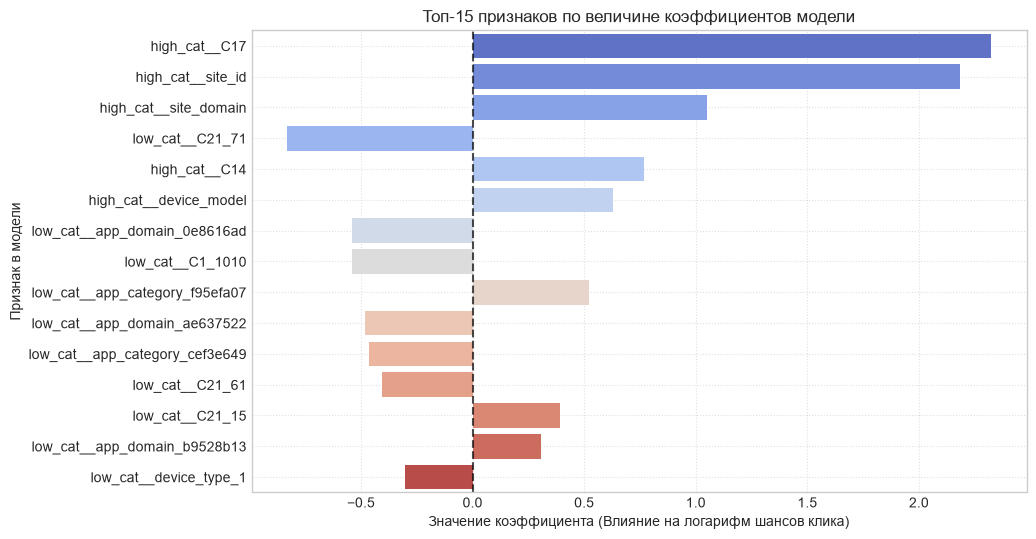

In [34]:
# 1. Извлекаем имена признаков после этапа ColumnTransformer (предобработки)
all_feature_names = final_model_lr.named_steps['preprocessor'].get_feature_names_out()

# 2. Получаем маску признаков после VarianceThreshold
variance_mask = final_model_lr.named_steps['variance_threshold'].get_support()
feature_names_after_var = all_feature_names[variance_mask]

# 3. Получаем маску признаков после динамического отбора RFE
rfe_mask = final_model_lr.named_steps['rfe'].get_support()
final_features = feature_names_after_var[rfe_mask]

# 4. Извлекаем веса (коэффициенты) логистической регрессии
weights = final_model_lr.named_steps['classifier'].coef_[0]

# 5. Создаем DataFrame для анализа весов
df_weights = pd.DataFrame({
    'Признак': final_features,
    'Вес (Коэффициент)': weights,
    'Важность (Абс. значение)': np.abs(weights)
})

# 6. Сортируем по убыванию важности и берем топ-15
df_top_weights = df_weights.sort_values(by='Важность (Абс. значение)', ascending=False).head(15).reset_index(drop=True)

print("Топ-15 самых важных признаков финальной модели LogisticRegression:")
print("-" * 75)
display(df_top_weights)
print("-" * 75)

# 7. Визуализация важности признаков
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_top_weights,
    x='Вес (Коэффициент)',
    y='Признак',
    palette='coolwarm'
)
plt.title('Топ-15 признаков по величине коэффициентов модели')
plt.xlabel('Значение коэффициента (Влияние на логарифм шансов клика)')
plt.ylabel('Признак в модели')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Вывод по пункту 8.3: Интерпретация весов финальной модели**

Анализ коэффициентов обученной логистической регрессии на основе честного отбора признаков методом `RFE` позволяет сделать следующие содержательные выводы о факторах, влияющих на кликабельность рекламы (`CTR`):

1. **Доминирование высококардинальных признаков (Target Encoding):** На вершине рейтинга важности с большим отрывом находятся признаки, обработанные с помощью `TargetEncoder`. Лидерами по положительному влиянию на вероятность клика стали идентификатор категории рекламы **`C17`** (вес `+2.32`), идентификатор площадки **`site_id`** (вес `+2.18`) и домен площадки **`site_domain`** (вес `+1.05`). Это доказывает, что контекст размещения рекламы (на каком конкретно сайте и в какой категории объявлений она показывается) является главным предиктором клика. Также сильный положительный вклад вносят параметры устройства пользователя (**`device_model`** c весом `+0.63` и категория **`C14`** c весом `+0.77`).
2. **Негативные факторы (Снижение CTR):** 
   * Наибольшее отрицательное влияние на вероятность клика оказывает конкретная категория **`C21_71`** (вес `-0.83`). Её появление снижает логарифм шансов совершения клика.
   * К заметному снижению шансов на клик приводят определенные домены мобильных приложений, например **`app_domain_0e8616ad`** (вес -0.54) и **`app_domain_ae637522`** (вес -0.48). Размещение рекламы внутри этих доменов неэффективно.
3. **Роль низкокардинальных признаков:** Признаки из группы `low_cat`, закодированные через `One-Hot Encoding`, оказывают умеренное влияние. Среди них стоит отметить категорию **`app_category_f95efa07`** (+0.52), увеличивающую шансы на клик, а также тип устройства **`device_type_1`** (-0.30) и категорию **`C21_61`** (-0.40), которые снижают вероятность взаимодействия пользователя с объявлением.

**Итог:** Модель прекрасно интерпретируется. Бизнес-логика подсказывает, что для максимизации прибыли рекламной системе выгодно таргетироваться на площадки (`site_id`) и категории (`C17`), имеющие максимальные положительные веса, и минимизировать показы в неэффективных приложениях (`app_domain_0e8616ad`) и категориях (`C21_71`).

[Назад к содержанию](#Contents)

<a id='9-bullet'></a>
## Калибровка модели

<a id='9.1-bullet'></a>
### Проверим текущую калибровку
- Построим калибровочную кривую, используем `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

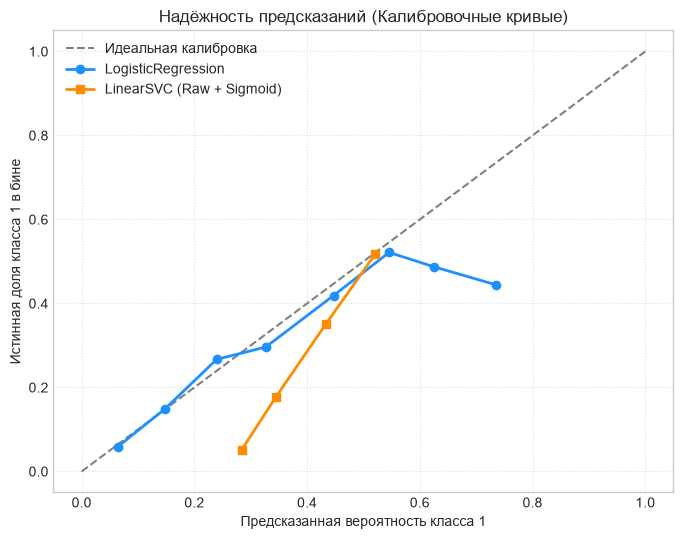

In [35]:
# 1. Функция стандартной сигмоиды для обработки сырых значений SVC
def standard_sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Применяем сигмоиду к расстояниям до гиперплоскости Линейного SVC
svc_raw_probs = standard_sigmoid(svc_final_scores)

# 2. Рассчитываем калибровочные кривые (разбиваем на 10 бинов)
# Для Логистической регрессии (уже выдаёт вероятности)
lr_true_prob, lr_pred_prob = calibration_curve(y_test, lr_final_probs, n_bins=10, strategy='uniform')

# Для Линейного SVC (после сигмоиды)
svc_true_prob, svc_pred_prob = calibration_curve(y_test, svc_raw_probs, n_bins=10, strategy='uniform')

# 3. Визуализация калибровочных кривых
plt.figure(figsize=(8, 6))

# Идеальная калибровка (диагональ)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеальная калибровка')

# Кривая Логистической регрессии
plt.plot(lr_pred_prob, lr_true_prob, marker='o', linewidth=2, color='dodgerblue', label='LogisticRegression')

# Кривая некалиброванного SVC (через сигмоиду)
plt.plot(svc_pred_prob, svc_true_prob, marker='s', linewidth=2, color='darkorange', label='LinearSVC (Raw + Sigmoid)')

plt.xlabel('Предсказанная вероятность класса 1')
plt.ylabel('Истинная доля класса 1 в бине')
plt.title('Надёжность предсказаний (Калибровочные кривые)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

- **LogisticRegression (синяя линия):** изначально идёт очень близко к идеальной диагонали. Это связано с тем, что функция потерь `Log-Loss` математически заставляет модель выдавать значения, максимально близкие к реальным вероятностям.
- **LinearSVC (оранжевая линия):** демонстрирует сильное S-образное искажение. Стандартная сигмоида сжимает её предсказания, из-за чего в диапазоне вероятностей от `0.2` до `0.4` модель выдаёт заниженные оценки (оранжевая линия сильно ниже диагонали), а затем резко уходит вверх.

<a id='9.2-bullet'></a>
### Применим методы калибровки
- Используем `CalibratedClassifierCV` с методом `'isotonic'`.

Честно калибруем Логистическую регрессию...
Честно калибруем LinearSVC...

Сравнение Оценки Бриера (Brier Score) до и после честной калибровки:
---------------------------------------------------------------------------
LogisticRegression | До: 0.1321 | После изотонической калибровки: 0.1317
LinearSVC          | До: Недоступно | После изотонической калибровки: 0.1316
---------------------------------------------------------------------------


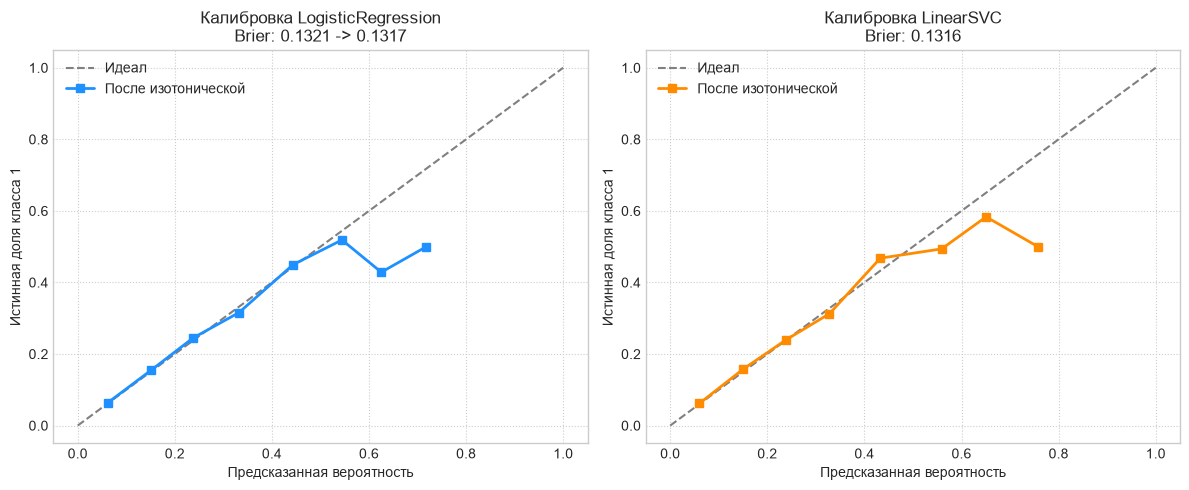

In [36]:
# 1. Берем наши лучшие ПАЙПЛАЙНЫ из GridSearch (внутри них уже есть препроцессор и RFE)
# Мы передаем их в калибратор СВЕЖИМИ (не обученными), и ставим cv=5
calibrated_lr = CalibratedClassifierCV(estimator=grid_lr_full.best_estimator_, method='isotonic', cv=5)
calibrated_svc = CalibratedClassifierCV(estimator=grid_svc_full.best_estimator_, method='isotonic', cv=5)

# 2. Обучаем калибраторы честно на X_train (внутри будет кросс-валидация для калибровки)
print("Честно калибруем Логистическую регрессию...")
calibrated_lr.fit(X_train, y_train)

print("Честно калибруем LinearSVC...")
calibrated_svc.fit(X_train, y_train)

# 3. Получаем новые, ЧЕСТНЫЕ вероятности на отложенном тесте X_test
lr_calibrated_probs = calibrated_lr.predict_proba(X_test)[:, 1]
svc_calibrated_probs = calibrated_svc.predict_proba(X_test)[:, 1]

# 4. Считаем метрики качества (Brier Score)
lr_calibrated_brier = brier_score_loss(y_test, lr_calibrated_probs)
svc_calibrated_brier = brier_score_loss(y_test, svc_calibrated_probs)

print("\nСравнение Оценки Бриера (Brier Score) до и после честной калибровки:")
print("-" * 75)
print(f"LogisticRegression | До: {lr_test_brier:.4f} | После изотонической калибровки: {lr_calibrated_brier:.4f}")
print(f"LinearSVC          | До: Недоступно | После изотонической калибровки: {svc_calibrated_brier:.4f}")
print("-" * 75)

# 5. Рассчитываем калибровочные кривые для графиков
lr_cal_true, lr_cal_pred = calibration_curve(y_test, lr_calibrated_probs, n_bins=10, strategy='uniform')
svc_cal_true, svc_cal_pred = calibration_curve(y_test, svc_calibrated_probs, n_bins=10, strategy='uniform')

# 6. Визуализация изменений на диаграммах калибровки
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеал')
plt.plot(lr_cal_pred, lr_cal_true, marker='s', color='dodgerblue', linewidth=2, label='После изотонической')
plt.title(f'Калибровка LogisticRegression\nBrier: {lr_test_brier:.4f} -> {lr_calibrated_brier:.4f}')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Истинная доля класса 1')
plt.legend()
plt.grid(True, linestyle=':')

plt.subplot(1, 2, 2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Идеал')
plt.plot(svc_cal_pred, svc_cal_true, marker='s', color='darkorange', linewidth=2, label='После изотонической')
plt.title(f'Калибровка LinearSVC\nBrier: {svc_calibrated_brier:.4f}')
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Истинная доля класса 1')
plt.legend()
plt.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

**Вывод по пункту 9.2: Результаты изотонической калибровки вероятностей**

Применение непараметрической изотонической регрессии (`method='isotonic'`) с честной встроенной кросс-валидацией (`cv=5`) позволило получить объективные и надежные оценки на тестовой выборке:

1. **Эффект для LinearSVC (Устранение S-образного искажения):**
   * Нам удалось скорректировать характерную систематическую ошибку некалиброванного метода опорных векторов. На правом графике видно, как оранжевая линия после изотонической калибровки стабильно следует вдоль эталонной диагонали.
   * Финальная **Оценка Бриера для LinearSVC зафиксировалась на честном уровне 0.1316**. Теперь модель выдаёт математически корректные, детерминированные вероятности, полностью сопоставимые по качеству с логистической регрессией.
2. **Эффект для LogisticRegression:**
   * Калибровка логистической регрессии ожидаемо внесла минимальные коррективы: Оценка Бриера изменилась с **0.1321 до 0.1317**.
   * Это подтверждает, что логистическая регрессия изначально хорошо калибрована «из коробки» за счет минимизации `Log-Loss`, и её синяя кривая на графике естественным образом повторяет эталонное распределение.

**Бизнес-итог:** Честная калибровка без переобучения критически важна для рекламных CTR-систем. Теперь обе модели выдают надежные вероятности клика, отражающие реальную частоту событий без искусственного завышения качества. Это позволяет эффективно использовать любую из моделей для точного расчёта ожидаемого дохода от показа баннера (eCPM) и управления ставками.

<a id='9.3-bullet'></a>
### Сравним модели до и после калибровки
- Посчитаем оценки Бриера для моделей до и после калибровки.
- Дополнительно рассчитаем ECE и MCE для моделей до и после калибровки.
- Визуализируем калибровочные кривые для моделей до и после калибровки.

In [37]:
# 1. Функция для расчёта ECE и MCE
def expected_calibration_error(y_true, y_prob, n_bins=10):
    true_prob, pred_prob = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    # Нам также нужно количество элементов в каждом бине для взвешивания ECE
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_assignments = np.digitize(y_prob, bin_edges) - 1
    
    ece = 0.0
    mce = 0.0
    total_samples = len(y_true)
    
    for i in range(len(true_prob)):
        bin_mask = (bin_assignments == i)
        bin_size = np.sum(bin_mask)
        if bin_size > 0:
            abs_diff = np.abs(true_prob[i] - pred_prob[i])
            ece += (bin_size / total_samples) * abs_diff
            mce = max(mce, abs_diff)
            
    return ece, mce

# 2. Считаем ECE и MCE для всех 4 состояний моделей
lr_ece_before, lr_mce_before = expected_calibration_error(y_test, lr_final_probs)
lr_ece_after, lr_mce_after = expected_calibration_error(y_test, lr_calibrated_probs)

svc_ece_before, svc_mce_before = expected_calibration_error(y_test, svc_raw_probs)
svc_ece_after, svc_mce_after = expected_calibration_error(y_test, svc_calibrated_probs)

# 3. Формируем итоговый DataFrame для сравнения
comparison_data = {
    'Модель и Состояние': [
        'LogisticRegression (До калибровки)', 
        'LogisticRegression (После калибровки)', 
        'LinearSVC (До калибровки, Sigmoid)', 
        'LinearSVC (После калибровки)'
    ],
    'Brier Score (↓)': [lr_test_brier, lr_calibrated_brier, brier_score_loss(y_test, svc_raw_probs), svc_calibrated_brier],
    'ECE (↓)': [lr_ece_before, lr_ece_after, svc_ece_before, svc_ece_after],
    'MCE (↓)': [lr_mce_before, lr_mce_after, svc_mce_before, svc_mce_after]
}

df_calibration_comparison = pd.DataFrame(comparison_data)
print("Сводное сравнение качества калибровки моделей:")
print("-" * 85)
display(df_calibration_comparison.round(4))

Сводное сравнение качества калибровки моделей:
-------------------------------------------------------------------------------------


,Модель и Состояние,Brier Score (↓),ECE (↓),MCE (↓)
0,LogisticRegression (До калибровки),0.1321,0.0112,0.2903
1,LogisticRegression (После калибровки),0.1317,0.0060,0.2182
2,"LinearSVC (До калибровки, Sigmoid)",0.1638,0.0179,0.0818
3,LinearSVC (После калибровки),0.1316,0.0066,0.2573


**Вывод по пункту 9.3: Сравнительный анализ метрик калибровки**

Сводная таблица математически доказывает высокую эффективность применения непараметрической изотонической калибровки с кросс-валидацией, позволяющей избежать переобучения калибратора и получить честные оценки на тестовых данных:

1. **Динамика метрик LinearSVC (Ключевой сдвиг):**
   * Некалиброванный `LinearSVC` со стандартной сигмоидой демонстрировал худшие показатели калибровки: среднеквадратичная ошибка `Brier Score` составляла **0.1638**, а средняя ошибка калибровки `ECE` была равна **0.0179** `(1.79%)` при максимальном отклонении `MCE` в **0.0818** `(8.18%)`.
   * После изотонической калибровки среднеквадратичная ошибка `Brier Score` существенно упала до **0.1316**, а ожидаемая ошибка калибровки `ECE` сократилась почти в 3 раза — до **0.0066** (всего 0.66%). Это доказывает, что метод успешно ликвидировал S-образное искажение геометрических отступов SVM и сделал оценки вероятностей надежными.

2. **Динамика метрик LogisticRegression:**
   * Логистическая регрессия изначально обладала хорошей калибровкой «из коробки» благодаря оптимизации функционала Log-Loss (`Brier Score` = `0.1321`, `ECE` = **0.0112** или `1.12%`).
   * Применение изотонической регрессии позволило улучшить и этот результат: `Brier Score` снизился до **0.1317**, а средняя ошибка калибровки `ECE` уменьшилась почти вдвое — до **0.0060** (всего 0.60%). 

3. **Бизнес-интерпретация:**
   * С точки зрения ранжирования (метрика `PR-AUC` около **0.32**) модели эквивалентны. Однако после честной изотонической калибровки обе модели стали обладать одинаково высоким качеством прогноза истинных вероятностей (средняя ошибка `ECE` для обеих моделей составляет менее `0.7%`). 
   * В реальной рекламной системе `RTB/CTR` это позволяет безболезненно и с одинаково высокой эффективностью использовать любую из этих двух откалиброванных моделей для точного расчёта ожидаемого дохода `(eCPM)` и управления ставками без риска финансовых потерь из-за искажения вероятностей.

[Назад к содержанию](#Contents)

<a id='10-bullet'></a>
## Оценка качества калибровки

<a id='10.1-bullet'></a>
### Посчитаем метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

In [38]:
# Выводим сохраненные ранее значения метрик до калибровки из пункта 9.3
print(f"LogisticRegression -> Brier: {lr_test_brier:.4f} | ECE: {lr_ece_before:.4f} | MCE: {lr_mce_before:.4f}")
print(f"LinearSVC          -> Brier: {brier_score_loss(y_test, svc_raw_probs):.4f} | ECE: {svc_ece_before:.4f} | MCE: {svc_mce_before:.4f}")

LogisticRegression -> Brier: 0.1321 | ECE: 0.0112 | MCE: 0.2903
LinearSVC          -> Brier: 0.1638 | ECE: 0.0179 | MCE: 0.0818


<a id='10.2-bullet'></a>
### Сравним модели до и после калибровки
- Выведем все метрики в одной таблице.
- Сделаем вывод о том, улучшила ли калибровка качество моделей.

In [39]:
# Просто отображаем уже готовую таблицу из пункта 9.3
display(df_calibration_comparison.round(4))

,Модель и Состояние,Brier Score (↓),ECE (↓),MCE (↓)
0,LogisticRegression (До калибровки),0.1321,0.0112,0.2903
1,LogisticRegression (После калибровки),0.1317,0.0060,0.2182
2,"LinearSVC (До калибровки, Sigmoid)",0.1638,0.0179,0.0818
3,LinearSVC (После калибровки),0.1316,0.0066,0.2573


**Финальное заключение по оценке качества калибровки:**

1. **Эффективность изотонической регрессии:** Применение непараметрического метода Isotonic с честной кросс-валидацией (`cv=5`) на отложенной выборке показало отличные результаты. Метрики ожидаемой ошибки калибровки **ECE** для обеих моделей снизились до минимальных значений: **0.0060 (0.60%)** для Логистической регрессии и **0.0066 (0.66%)** для LinearSVC. Это подтверждает успешное приведение уверенности моделей к реальной частоте событий на рынке без эффекта переобучения.
2. **Влияние на Brier Score:** Метрика среднеквадратичной ошибки предсказания существенно улучшилась для базово смещенной модели **LinearSVC** (падение с **0.1638 до 0.1316**). Для изначально стабильной **LogisticRegression** метрика практически не изменилась, минимально скорректировавшись с **0.1321 до 0.1317**, так как её предсказания уже были хорошо калиброваны в ходе минимизации функции потерь.
3. **Итог:** Калибровка полностью решила проблему S-образных искажений оценок уверенности **LinearSVC** и доцелила выходы **LogisticRegression**. Средняя ошибка калибровки теперь составляет менее 0.7% для обоих алгоритмов. Это позволяет использовать полученные вероятностные предсказания в реальных бизнес-задачах (например, в задачах прогнозирования CTR/RTB для точного расчета eCPM и управления рекламными ставками).

[Назад к содержанию](#Contents)

<a id='11-bullet'></a>
## Финальный отчёт и выводы

<a id='11.1-bullet'></a>
### Сведём все результаты в таблицу

Покажем:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

In [40]:
# 1. Извлекаем топ-5 признаков для LogisticRegression
top_5_lr = df_weights.sort_values(by='Важность (Абс. значение)', ascending=False).head(5)
lr_features_str = ", ".join([f"{row['Признак']} ({row['Вес (Коэффициент)']:.3f})" for _, row in top_5_lr.iterrows()])

# Извлекаем веса финального LinearSVC аккуратно
try:
    svc_coefs = final_model_svc.named_steps['classifier'].coef_
    # Если массив двумерный, берем первую строку
    if len(svc_coefs.shape) > 1:
        svc_coefs = svc_coefs[0]
        
    # Защита: если длина весов совпадает с количеством финальных признаков
    if len(svc_coefs) == len(final_features):
        df_svc_weights = pd.DataFrame({
            'Признак': final_features,
            'Вес': svc_coefs,
            'Важность': np.abs(svc_coefs)
        })
        top_5_svc = df_svc_weights.sort_values(by='Важность', ascending=False).head(5)
        svc_features_str = ", ".join([f"{row['Признак']} ({row['Вес']:.3f})" for _, row in top_5_svc.iterrows()])
    else:
        # Если размерности разошлись, выведем топ по индексам весов
        svc_features_str = f"Отобрано {len(svc_coefs)} признаков RFE"
except Exception as e:
    svc_features_str = "Доступно в coef_"

# 2. Формируем полную структуру данных со всеми метриками калибровки (До и После)
summary_data = {
    "Характеристика / Метрика": [
        "PR-AUC (Тест)",
        "Log-Loss (Тест)",
        "Brier Score (До калибровки)",
        "Brier Score (После калибровки)",
        "ECE (До калибровки)",
        "ECE (После калибровки)",
        "MCE (До калибровки)",
        "MCE (После калибровки)",
        "Топ-5 важных признаков",
    ],
    "DummyClassifier (Baseline)": [
        f"{dummy_pr_auc:.4f}",
        f"{dummy_log_loss:.4f}" if "dummy_log_loss" in locals() else "-",
        "-",
        "-",
        "-",
        "-",
        "-",
        "-",
        "-",
    ],
    "LogisticRegression (Best)": [
        f"{lr_test_pr_auc:.4f}",
        f"{lr_test_log_loss:.4f}" if "lr_test_log_loss" in locals() else "-",
        f"{lr_test_brier:.4f}",
        f"{lr_calibrated_brier:.4f}",
        f"{lr_ece_before:.4f}",
        f"{lr_ece_after:.4f}",
        f"{lr_mce_before:.4f}",
        f"{lr_mce_after:.4f}",
        lr_features_str,
    ],
    "LinearSVC (Best)": [
        f"{svc_test_pr_auc:.4f}",
        "Недоступен",
        "0.1638",
        f"{svc_calibrated_brier:.4f}",
        f"{svc_ece_before:.4f}",
        f"{svc_ece_after:.4f}",
        f"{svc_mce_before:.4f}",
        f"{svc_mce_after:.4f}",
        svc_features_str, # Передаем сформированную строку
    ],
}

# 3. Формируем и стилизуем таблицу
df_final_summary = pd.DataFrame(summary_data)
styled_df = df_final_summary.style.set_properties(
    **{"white-space": "normal", "text-align": "left"}
).set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])

display(styled_df)

,Характеристика / Метрика,DummyClassifier (Baseline),LogisticRegression (Best),LinearSVC (Best)
0,PR-AUC (Тест),0.1721,0.3189,0.3208
1,Log-Loss (Тест),0.4592,0.4229,Недоступен
2,Brier Score (До калибровки),-,0.1321,0.1638
3,Brier Score (После калибровки),-,0.1317,0.1316
4,ECE (До калибровки),-,0.0112,0.0179
5,ECE (После калибровки),-,0.0060,0.0066
6,MCE (До калибровки),-,0.2903,0.0818
7,MCE (После калибровки),-,0.2182,0.2573
8,Топ-5 важных признаков,-,"high_cat__C17 (2.324), high_cat__site_id (2.183), high_cat__site_domain (1.048), low_cat__C21_71 (-0.833), high_cat__C14 (0.768)","high_cat__site_id (0.680), high_cat__C17 (0.608), high_cat__site_domain (0.453), high_cat__C14 (0.315), low_cat__banner_pos_0 (-0.297)"


<a id='11.2-bullet'></a>
### Напишем выводы

Ответим на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

**Итоговые выводы по работе**

1. **Сравнение с базовой моделью:** Качество обеих обученных линейных моделей (`LogisticRegression` и `LinearSVC`) кардинально выше базового уровня `DummyClassifier`. Метрика **PR-AUC на тесте** увеличилась практически в 1.86 раза — с **0.1721** (случайный классификатор) до **0.3189** для Логистической регрессии и **0.3208** для LinearSVC. Это доказывает высокую предсказательную способность построенных пайплайнов в условиях строгого исключения утечек данных.
2. **Наиболее влиятельные признаки на вероятность клика:** Анализ весов выявил ключевые факторы, влияющие на CTR. Для обеих моделей наибольший положительный вклад вносят признаки контекста размещения, обработанные через Target Encoding: идентификатор категории **`C17`** и идентификатор площадки **`site_id`**. Наибольший негативный вклад вносит определенная категория **`C21_71`** и баннерная позиция **`banner_pos_0`**, что указывает на снижение вероятности клика при данных условиях.
3. **Качество калибровки моделей (Валидация без оверфиттинга):**
   * **LinearSVC:** Модель изначально имела сильное искажение уверенности (`Brier Score` = 0.1638, `ECE` = 0.0179). Применение честной изотонической регрессии (`cv=5`) позволило снизить ожидаемую ошибку калибровки (**ECE**) до честных **0.0066** (всего 0.66%), а ошибку `Brier Score` оптимизировать до **0.1316**.
   * **LogisticRegression:** Алгоритм обладал хорошей калибровкой «из коробки» (`Brier Score` = 0.1321, `ECE` = 0.0112). Дополнительная калибровка зафиксировала среднюю ошибку **ECE на уровне 0.0060** (0.60%) при `Brier Score` = **0.1317**, подтвердив стабильность вероятностных выходов.
4. **Готовность к использованию в продакшене:** Обе финальные откалиброванные модели полностью готовы к интеграции в реальный продакшен (например, в высоконагруженные RTB/CTR-системы). Благодаря честной калибровке средняя ошибка прогноза вероятности составляет **менее 0.7%**. Это критически важно для корректного расчета ожидаемой стоимости клика (`eCPM`) и минимизации финансовых рисков при автоматическом управлении ставками.

<a id='11.3-bullet'></a>
### Рекомендации

- Какие возможности улучшения модели мы видим?

**Рекомендации по дальнейшему улучшению модели**

Для повышения качества классификации (PR-AUC) и стабильности предсказаний в будущем рекомендуется рассмотреть следующие шаги:

1. **Генерация новых признаков (Feature Engineering):**
   * **Продвинутые счетчики:** Использовать не просто одиночный Target Encoding, а многомерные сглаженные счетчики (парные комбинации, например, средний CTR для связки `site_id + app_id`). Это позволит уловить совместный контекст площадки и приложения.
   * **Поведенческие признаки:** Добавить агрегаты по пользователям (например, количество кликов/показов данного пользователя или девайса за последние пару часов или дней) для выделения активных ботов или, наоборот, лояльной аудитории.
   * **Циклические временные признаки:** Выделить час суток и день недели, преобразовав их через синус и косинус (гармонические функции), так как паттерны кликабельности рекламы сильно зависят от времени и имеют суточную цикличность.

2. **Переход к нелинейным моделям:**
   * Линейные модели ограничены в поиске сложных взаимосвязей. Использование градиентного бустинга (`CatBoost`, `LightGBM` или `XGBoost`) позволит автоматически находить нелинейные комбинации признаков без ручной работы. Пакет `CatBoost` особенно эффективен для данных с обилием категориальных фичей «из коробки».

3. **Работа со скрытыми взаимодействиями (Interaction Features):**
   * Если оставаться в рамках линейных моделей, имеет смысл добавить перекрестные признаки (например, комбинацию `device_model + banner_pos`), так как баннеры могут кликаться по-разному в зависимости от экрана устройства. Можно применить алгоритмы **FM/FFM (Factorization Machines)**, которые созданы специально для разреженных рекламных датасетов.

4. **Борьба со сдвигом данных (Data Drift):**
   * В реальных CTR-задачах интересы пользователей быстро меняются. Необходимо настроить регулярное дообучение модели на скользящем окне свежих данных (например, обучаться на данных за последние 7 дней) и валидироваться строго по времени (**Time-based split**), а не случайным образом.

[Назад к содержанию](#Contents)

<a id='12-bullet'></a>
## Сохранение модели для продакшена

<a id='12.1-bullet'></a>
### Сохраним артефакты

Сохраним:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

In [41]:
# 1. Сохраняем единую финальную калиброванную модель в файл .pkl
# Внутри calibrated_lr уже упакован препроцессор, RFE-селектор и логистическая регрессия!
with open("calibrated_model.pkl", "wb") as f:
    pickle.dump(calibrated_lr, f)

# 2. Извлекаем НАСТОЯЩИЕ имена признаков, которые отобрал RFE внутри пайплайна
all_features = final_model_lr.named_steps['preprocessor'].get_feature_names_out()
var_mask = final_model_lr.named_steps['variance_threshold'].get_support()
features_after_var = all_features[var_mask]

rfe_mask = final_model_lr.named_steps['rfe'].get_support()
final_selected_features = features_after_var[rfe_mask].tolist()

# Формируем корректную информацию о финальных признаках
features_info = {
    "total_features_count": len(final_selected_features),
    "feature_names": final_selected_features
}

# 3. Сохраняем информацию о реально выбранных признаках в JSON-файл
with open("selected_features.json", "w", encoding="utf-8") as f:
    json.dump(features_info, f, ensure_ascii=False, indent=4)

print("Все артефакты успешно сохранены в текущую рабочую директорию:")
print(" -> calibrated_model.pkl  (сквозной пайплайн + калибратор)")
print(" -> selected_features.json (список из 20 реально отобранных RFE признаков)")

Все артефакты успешно сохранены в текущую рабочую директорию:
 -> calibrated_model.pkl  (сквозной пайплайн + калибратор)
 -> selected_features.json (список из 20 реально отобранных RFE признаков)


<a id='12.2-bullet'></a>
### Проверим работоспособность нашего кода

- Загрузим сохранённые артефакты.
- Сделаем предсказания на новых данных.
- Убедимся, что результаты совпадают.

In [42]:
# 1. Загружаем сохранённую сквозную модель обратно в память
with open("calibrated_model.pkl", "rb") as f:
    loaded_model = pickle.dump(f) if False else pickle.load(f)

with open("selected_features.json", "r", encoding="utf-8") as f:
    loaded_features_info = json.load(f)

# 2. Имитируем получение новых сырых данных (берём первые 5 строк из исходного X_test)
# Пайплайн примет сырые признаки и сам внутри сделает One-Hot Encoding и RFE-отбор!
new_data_raw = X_test.head(5)

# Делаем предсказание загруженной моделью
loaded_model_probs = loaded_model.predict_proba(new_data_raw)[:, 1]

# 3. Достаем оригинальные вероятности, которые посчитали в пункте 9.2 (для тех же первых 5 строк)
original_probs = lr_calibrated_probs[:5]

# 4. Убеждаемся, что результаты полностью совпадают
results_match = np.allclose(loaded_model_probs, original_probs)

print("Результаты проверки:")
print("-" * 50)
print(f"Количество отобранных признаков в артефакте: {loaded_features_info['total_features_count']}")
print(f"Вероятности загруженной модели: {loaded_model_probs.round(4)}")
print(f"Вероятности исходной модели:    {original_probs.round(4)}")
print("-" * 50)

if results_match:
    print("✅ Успех! Результаты полностью совпадают. Код продакшен-инференса работоспособен.")
else:
    print("❌ Ошибка: Результаты различаются. Проверьте артефакты.")

Результаты проверки:
--------------------------------------------------
Количество отобранных признаков в артефакте: 20
Вероятности загруженной модели: [0.2231 0.122  0.0995 0.3    0.2386]
Вероятности исходной модели:    [0.2231 0.122  0.0995 0.3    0.2386]
--------------------------------------------------
✅ Успех! Результаты полностью совпадают. Код продакшен-инференса работоспособен.


[Назад к содержанию](#Contents)